# DYSLEXIA SCREENING SYSTEM — PHASE 3
## Domain Adaptation via Maximum Mean Discrepancy (MMD)

---

### 📋 Project Overview
This phase focuses on bridging the domain gap between high-fidelity clinical hardware and consumer-grade webcams using **Unsupervised Domain Adaptation (UDA)**.

| Domain | Dataset | Hardware | Frequency | Status |
| :--- | :--- | :--- | :--- | :--- |
| **Source** | **ETDD70** | Clinical Eye-Tracker | 250 Hz | Labelled |
| **Target** | **WebQAmGaze** | Standard Webcam | 30 Hz | Unlabelled |

###  Strategy: MMD Alignment
The model minimizes a composite loss function to ensure that features extracted from the webcam (Target) resemble those from the clinical tracker (Source) in a high-dimensional Hilbert space.

$$L_{total} = L_{classification}(source) + \lambda(t) \cdot L_{MMD}(source\_emb, target\_emb)$$

#### Why MMD over GAN-based Discriminators?
*   **Stability:** No minimax instability; avoids the "cat-and-mouse" training dynamics of adversarial networks.
*   **Efficiency:** Features a closed-form differentiable loss, requiring only a single backward pass.
*   **Multi-Kernel Support:** Captures alignment at multiple length scales simultaneously.
*   **Convergence:** Prevents "discriminator domination," a failure mode observed during Phase 2 UDA attempts.

---

### 🛠 Implementation Details
*   **Platform:** Kaggle (GPU Accelerator Recommended)
*   **Methodology:** Aligning latent space embeddings to ensure cross-domain generalizability.

###  Required Artefacts (Phase 2)
*To run this module, ensure the following files are mounted as a Kaggle dataset:*

| Artefact Name | Description |
| :--- | :--- |
| `best_reading_profile_v3_kfold.keras` | Pre-trained classification weights. |
| `gaze_encoder_v3.keras` | Base feature extraction architecture. |
| `scaler_v3_etdd70_final.pkl` | Standardized normalization parameters. |
| `optimal_threshold.txt` | Pre-calculated decision boundary for screening. |

---
*Developed for Phase 3: Research & Development Pipeline*

# BLOCK 0 — Install dependencies

In [1]:
!pip install pymovements --quiet
!pip install tensorflow --quiet
!pip install --upgrade --force-reinstall numpy scipy scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.0/309.0 kB 1.9 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 18.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.4/833.4 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 25.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.3/788.3 kB 44.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-polars-cu12 26.2.1 requires polars<1.36,>=1.30, but you have polars 1.41.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 822.1 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 52.8 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behav

# BLOCK 1 — Imports & Global Constants
# ALL I-DT / feature constants are identical to ETDD70 Phase 2.
# Any divergence here means the encoder maps different semantics.

In [2]:
import os
import glob
import pickle
import warnings
import scipy
import tqdm
import sklearn
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import uniform_filter1d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_curve, auc)
from collections import defaultdict
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Dropout, TimeDistributed,
    GlobalAveragePooling1D, Concatenate, Masking, Lambda
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau)

2026-06-19 20:12:07.510486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781899927.703227      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781899927.757083      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781899928.206535      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781899928.206575      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781899928.206578      58 computation_placer.cc:177] computation placer alr

In [3]:
import os, glob, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.ndimage import uniform_filter1d
from scipy.stats import mannwhitneyu, ks_2samp
from sklearn.manifold import TSNE
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, f1_score)
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow.keras.layers import (Input, Dense, Dropout, TimeDistributed,
                                      Concatenate, LayerNormalization)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ReduceLROnPlateau

print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"tensorflow: {tf.__version__}")

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

# ── I-DT constants — MUST be identical to Phase 2 ────────────────────────────
DISPERSION_THRESHOLD = 0.041
DURATION_THRESHOLD_MS = 100
MAX_DURATION_MS       = 1500
GAP_THRESHOLD_MS      = 30.6      # blink-crossing mask threshold

# ── Feature engineering — MUST match Phase 2 ─────────────────────────────────
AMPLITUDE_FLOOR = 0.0001
AMPLITUDE_MAX   = 0.076948       # 95th-pct cap from ETDD70 training data
EFFICIENCY_CAP  = 20.0
EPSILON         = 1e-6

# ── Sequence parameters — MUST match Phase 2 ─────────────────────────────────
SEQUENCE_LENGTH = 20
STEP            = 5
N_FEATURES      = 6
SOURCE_MAX_LEN  = 40             # from Phase 2 (50th-pct cap)
LATENT_DIM      = 64

FEATURE_COLS = ['feat_duration','feat_x','feat_y',
                'feat_amplitude','feat_regression','feat_efficiency']

# ── MMD hyperparameters ───────────────────────────────────────────────────────
# λ starts small and ramps up — lets classification stabilise first
LAMBDA_MMD_FINAL = 0.1            # final MMD weight
LAMBDA_RAMP_EPOCHS = 20           # epochs to ramp from 0 → LAMBDA_MMD_FINAL

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE_SOURCE = 16            # participants per source batch
BATCH_SIZE_TARGET = 11            # sequences per target batch (no participant structure)
EPOCHS            = 80
LR_INITIAL        = 3e-4

# ── Pseudo-labelling (Phase 3b) ───────────────────────────────────────────────
PSEUDO_CONFIDENCE_THRESHOLD = 0.85   # |p - 0.5| > threshold → pseudo-label
PSEUDO_LABEL_EPOCHS         = 20
RUN_PSEUDO_LABELLING = False  # deferred until the adapted model's target
                               # predictions show real spread

# ── Paths ─────────────────────────────────────────────────────────────────────
PHASE2_DIR    = '/kaggle/input/datasets/muhammedomran/phase240'
WEBQAM_DIR    = '/kaggle/input/datasets/muhammedomran/mediapipe-with-reses/mediapipe_with_reses'
OUTPUT_DIR    = '/kaggle/working'

ENCODER_PATH    = '/kaggle/input/models/muhammedomran/gaze-encoder-v3/tensorflow2/default/1/gaze_encoder_v3.keras'
CLASSIFIER_PATH = '/kaggle/input/models/muhammedomran/best-reading-profile-v5/tensorflow2/default/1/best_reading_profile_v3_kfold.keras'
SCALER_PATH     = '/kaggle/input/models/muhammedomran/best-reading-profile-v5/tensorflow2/default/1/scaler_v3_etdd70_final.pkl'
#THRESHOLD_PATH  = '/kaggle/input/datasets/muhammedomran/kfold-v3/kfold_metrics_v3.csv'
DECISION_THRESHOLD = 0.462
print("Constants locked — all I-DT / feature params match Phase 2.")

numpy: 2.4.6
pandas: 2.3.3
matplotlib: 3.10.0
seaborn: 0.13.2
scipy: 1.18.0
scikit-learn: 1.9.0
tensorflow: 2.19.0
TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Constants locked — all I-DT / feature params match Phase 2.


# BLOCK 2 — Load Phase-2 Artefacts

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 — Load Phase-2 Artefacts (manual rebuild + direct weight loading)
# ─────────────────────────────────────────────────────────────────────────────
import os
import zipfile
import tempfile
import pickle
import numpy as np
import tensorflow as tf
import keras
from keras.models import load_model


# ═════════════════════════════════════════════════════════════════════════════
# 1. Custom layers
# ═════════════════════════════════════════════════════════════════════════════

@keras.saving.register_keras_serializable()
class MaskedGlobalAvgPool(keras.layers.Layer):
    """
    Mask-aware global average pooling.

    Expects:
        x    : (B, T, F)
        mask : (B, T)

    Returns:
        (B, F)
    """

    def call(self, inputs, mask=None):
        # Support both:
        #   layer([x, mask])
        # and any accidental direct call variants.
        if isinstance(inputs, (list, tuple)) and len(inputs) == 2:
            x, mask_tensor = inputs
        else:
            x = inputs
            mask_tensor = mask

        if mask_tensor is None:
            # Fallback: plain global average over time
            return tf.reduce_mean(x, axis=1)

        mask_f = tf.cast(mask_tensor, x.dtype)
        mask_f = tf.expand_dims(mask_f, axis=-1)

        masked_sum = tf.reduce_sum(x * mask_f, axis=1)
        valid_count = tf.reduce_sum(mask_f, axis=1)

        return masked_sum / tf.maximum(valid_count, 1e-6)

    def compute_output_shape(self, input_shape):
        # Keras may pass:
        #   None
        # or:
        #   [(B, T, F), (B, T)]
        if input_shape is None:
            return (None, None)

        if isinstance(input_shape, (list, tuple)) and len(input_shape) > 0:
            x_shape = input_shape[0]
            if x_shape is not None and len(x_shape) >= 3:
                return (x_shape[0], x_shape[2])

        return (None, None)

    def compute_mask(self, inputs, mask=None):
        return None


print("✅ Custom layers registered.")


# ═════════════════════════════════════════════════════════════════════════════
# 2. Helpers
# ═════════════════════════════════════════════════════════════════════════════

def extract_member_from_keras_archive(archive_path: str, member_name: str, out_path: str) -> str:
    """
    Extract a single member from a .keras zip archive to out_path.
    """
    with zipfile.ZipFile(archive_path, "r") as z:
        if member_name not in z.namelist():
            raise FileNotFoundError(f"{member_name} not found in {archive_path}")
        with open(out_path, "wb") as f:
            f.write(z.read(member_name))
    return out_path


def load_weights_from_keras_archive(model: keras.Model, archive_path: str) -> None:
    """
    Load model.weights.h5 from a .keras archive into an already-built model.
    """
    with tempfile.TemporaryDirectory() as tmpdir:
        weights_path = os.path.join(tmpdir, "model.weights.h5")
        extract_member_from_keras_archive(archive_path, "model.weights.h5", weights_path)

        # Keras 3 can load the extracted H5 weight file directly.
        model.load_weights(weights_path)

    print("  [Weights] Loaded model.weights.h5 successfully.")


def build_phase2_encoder(
    sequence_length: int,
    n_features: int,
) -> keras.Model:
    """
    Rebuilds the inner encoder exactly as seen in the archived config.
    """
    encoder_input = keras.Input(
        shape=(sequence_length, n_features),
        name="encoder_input"
    )

    x = keras.layers.LSTM(
        128,
        return_sequences=True,
        return_state=False,
        trainable=True,        
        name="encoder_lstm_1",
    )(encoder_input)

    x = keras.layers.Dropout(0.08, name="encoder_dropout_1")(x)

    x_attn = keras.layers.MultiHeadAttention(
        num_heads=4,
        key_dim=16,
        value_dim=16,
        dropout=0.08,
        use_bias=True,
        attention_axes=(1,),
        name="encoder_mhsa",
    )(x, x)

    x_attn = keras.layers.Dropout(0.1, name="encoder_attention_dropout")(x_attn)

    x = keras.layers.Add(name="encoder_residual")([x, x_attn])

    x = keras.layers.LayerNormalization(
        axis=-1,
        epsilon=1e-6,
        name="encoder_layernorm",
    )(x)

    x = keras.layers.Dropout(0.1, name="encoder_post_norm_dropout")(x)

    encoder_output = keras.layers.LSTM(
        64,
        return_sequences=False,
        return_state=True,
        trainable=True,
        name="encoder_lstm_2",
    )(x)[0]

    encoder = keras.Model(
        encoder_input,
        encoder_output,
        name="gaze_encoder_v3",
    )
    return encoder


def build_phase2_classifier(
    source_max_len: int,
    sequence_length: int,
    n_features: int,
) -> keras.Model:
    """
    Rebuild the full classifier graph in code, then load weights.
    """
    meaningful_input = keras.Input(
        shape=(source_max_len, sequence_length, n_features),
        name="input_meaningful",
    )
    mask_input = keras.Input(
        shape=(source_max_len,),
        name="mask_meaningful",
    )

    encoder = build_phase2_encoder(sequence_length, n_features)

    x = keras.layers.TimeDistributed(
        encoder,
        name="shared_gaze_encoder",
    )(meaningful_input)

    x = MaskedGlobalAvgPool(name="masked_avg_pool")([x, mask_input])

    # NOTE:
    # These dense activations are the most likely binary-head setup.
    # If your training code used different activations, adjust here.
    x = keras.layers.Dense(64, activation="relu", name="head_dense_1")(x)
    x = keras.layers.Dropout(0.3, name="head_dropout_1")(x)

    x = keras.layers.Dense(32, activation="relu", name="head_dense_2")(x)
    x = keras.layers.Dropout(0.2, name="head_dropout_2")(x)

    output = keras.layers.Dense(1, activation="sigmoid", name="output_classifier")(x)

    model = keras.Model(
        inputs=[meaningful_input, mask_input],
        outputs=output,
        name="best_reading_profile_v3_kfold",
    )
    return model


# ═════════════════════════════════════════════════════════════════════════════
# 3. Load scaler
# ═════════════════════════════════════════════════════════════════════════════

print("\n--- Block 2: Loading Phase-2 Artefacts ---")
print("\n[1/4] Loading scaler ...")

with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)

print(f"  Path      : {SCALER_PATH}")
print(f"  means     : {np.round(scaler.mean_, 4)}")
print(f"  scales    : {np.round(scaler.scale_, 4)}")
print(f"  Threshold : {DECISION_THRESHOLD:.4f}")


# ═════════════════════════════════════════════════════════════════════════════
# 4. Load Phase-1 encoder for viz only
# ═════════════════════════════════════════════════════════════════════════════

print("\n[2/4] Loading Phase-1 encoder (viz only) ...")

encoder_frozen = load_model(
    ENCODER_PATH,
    custom_objects={"MaskedGlobalAvgPool": MaskedGlobalAvgPool},
    compile=False,
)

encoder_frozen.trainable = False

print(f"  Loaded : {encoder_frozen.name} (frozen — viz only)")
print(f"  Input  : {encoder_frozen.input_shape}")
print(f"  Output : {encoder_frozen.output_shape}")


# ═════════════════════════════════════════════════════════════════════════════
# 5. Rebuild and load Phase-2 classifier
# ═════════════════════════════════════════════════════════════════════════════

print("\n[3/4] Rebuilding Phase-2 classifier from code ...")

source_classifier = build_phase2_classifier(
    source_max_len=SOURCE_MAX_LEN,
    sequence_length=SEQUENCE_LENGTH,
    n_features=N_FEATURES,
)

print("  [Build] Model graph rebuilt.")
source_classifier.summary(line_length=100)

print("\n  [Load] Extracting and loading weights from .keras archive ...")
load_weights_from_keras_archive(source_classifier, CLASSIFIER_PATH)

print(f"\n[4/4] ✅ Phase-2 classifier loaded: {source_classifier.name}")
source_classifier.summary(line_length=100)


# ═════════════════════════════════════════════════════════════════════════════
# 6. Smoke test
# ═════════════════════════════════════════════════════════════════════════════

print("\n[Smoke test] Forward pass with real input shape ...")

dummy_x = tf.zeros([2, SOURCE_MAX_LEN, SEQUENCE_LENGTH, N_FEATURES], dtype=tf.float32)
dummy_mask = tf.ones([2, SOURCE_MAX_LEN], dtype=tf.float32)

out = source_classifier([dummy_x, dummy_mask], training=False)
assert out.shape == (2, 1), f"Unexpected output shape: {out.shape}"

print(f"  Fed    : {dummy_x.shape}  (SOURCE_MAX_LEN={SOURCE_MAX_LEN})")
print(f"  Output : {out.shape}  ✅")
print("\nAll Phase-2 artefacts loaded successfully.")

✅ Custom layers registered.

--- Block 2: Loading Phase-2 Artefacts ---

[1/4] Loading scaler ...
  Path      : /kaggle/input/models/muhammedomran/best-reading-profile-v5/tensorflow2/default/1/scaler_v3_etdd70_final.pkl
  means     : [1.967752e+02 7.268000e-01 5.261000e-01 1.770000e-02 3.252000e-01
 7.891700e+00]
  scales    : [8.18331e+01 3.03700e-01 2.37000e-01 1.55000e-02 4.68500e-01 3.87310e+00]
  Threshold : 0.4620

[2/4] Loading Phase-1 encoder (viz only) ...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
I0000 00:00:1781899940.145336      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


  Loaded : gaze_encoder_v3 (frozen — viz only)
  Input  : (None, 20, 6)
  Output : (None, 64)

[3/4] Rebuilding Phase-2 classifier from code ...
  [Build] Model graph rebuilt.


Model: "best_reading_profile_v3_kfold"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_meaningful            │ (None, 40, 20, 6)       │              0 │ -                       │
│ (InputLayer)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ shared_gaze_encoder         │ (None, 40, 64)          │        151,872 │ input_meaningful[0][0]  │
│ (TimeDistributed)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ mask_meaningful             │ (None, 40)              │              0 │ -                       │
│ (InputLayer)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ masked_avg_pool             │ (None, 64)              │              0 │ shared_gaze_encoder[0]… │
│ (MaskedGlobalAvgPool)       │                         │                │ mask_meaningful[0][0]   │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ head_dense_1 (Dense)        │ (None, 64)              │          4,160 │ masked_avg_pool[0][0]   │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ head_dropout_1 (Dropout)    │ (None, 64)              │              0 │ head_dense_1[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ head_dense_2 (Dense)        │ (None, 32)              │          2,080 │ head_dropout_1[0][0]    │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ head_dropout_2 (Dropout)    │ (None, 32)              │              0 │ head_dense_2[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ output_classifier (Dense)   │ (None, 1)               │             33 │ head_dropout_2[0][0]    │
└─────────────────────────────┴─────────────────────────┴────────────────┴─────────────────────────┘

...

 Trainable params: 158,145 (617.75 KB)

 Non-trainable params: 0 (0.00 B)


[Smoke test] Forward pass with real input shape ...


I0000 00:00:1781899942.029621     153 cuda_dnn.cc:529] Loaded cuDNN version 91002


  Fed    : (2, 40, 20, 6)  (SOURCE_MAX_LEN=40)
  Output : (2, 1)  ✅

All Phase-2 artefacts loaded successfully.


# BLOCK 3 — Load Source (ETDD70) Tensors
# These were saved at the end of Phase 2.

In [5]:
print("\n--- Block 3: Loading Source Tensors ---")

X_src_train = np.load(os.path.join(PHASE2_DIR, 'X_train_source.npy'))
X_src_val   = np.load(os.path.join(PHASE2_DIR, 'X_val_source.npy'))
mask_src_train = np.load(os.path.join(PHASE2_DIR, 'mask_train_mean.npy'))
mask_src_val   = np.load(os.path.join(PHASE2_DIR, 'mask_val_mean.npy'))
y_src_train = np.load(os.path.join(PHASE2_DIR, 'y_train_source.npy'))
y_src_val   = np.load(os.path.join(PHASE2_DIR, 'y_val_source.npy'))

print(f"X_src_train : {X_src_train.shape}   y_train: {y_src_train.shape}")
print(f"X_src_val   : {X_src_val.shape}     y_val  : {y_src_val.shape}")
print(f"mask_train  : {mask_src_train.shape}")
print(f"Source class balance — train  0:{(y_src_train==0).sum()} 1:{(y_src_train==1).sum()}")
print(f"Source class balance — val    0:{(y_src_val==0).sum()}   1:{(y_src_val==1).sum()}")


--- Block 3: Loading Source Tensors ---
X_src_train : (56, 40, 20, 6)   y_train: (56,)
X_src_val   : (14, 40, 20, 6)     y_val  : (14,)
mask_train  : (56, 40)
Source class balance — train  0:28 1:28
Source class balance — val    0:7   1:7


# BLOCK 4 — WebQAmGaze Preprocessing Helpers
# Exact same logic as ETDD70 Phase 2.
# Differences handled explicitly:
   • No binocular data  → no binocular averaging step
   • Blinks via spatial filter (x<0 or y<0 or x>W or y>H)
   • Screen dims read per-participant from JSON metadata

In [6]:
print("\n--- Block 4: Preprocessing Helpers ---")


def idt_fixations(gaze_x: np.ndarray, gaze_y: np.ndarray,
                  timestamps: np.ndarray,
                  screen_w: float, screen_h: float) -> pd.DataFrame:
    """
    Run I-DT on a single trial's raw gaze samples.
    gaze_x, gaze_y : raw pixel coordinates (already blink-filtered)
    timestamps      : ms timestamps
    Returns DataFrame with columns [onset_ms, duration_ms, cx_norm, cy_norm]
    """
    SCREEN_DIAG = np.sqrt(screen_w**2 + screen_h**2)
    nx = gaze_x / screen_w
    ny = gaze_y / screen_h

    fixations   = []
    i = 0
    N = len(nx)

    while i < N:
        j = i
        # Grow window until dispersion exceeds threshold
        while j < N:
            win_x = nx[i:j+1]
            win_y = ny[i:j+1]
            disp  = ((win_x.max() - win_x.min()) +
                     (win_y.max() - win_y.min()))
            if disp > DISPERSION_THRESHOLD:
                break
            j += 1

        dur_ms = timestamps[j-1] - timestamps[i] if j > i else 0

        if dur_ms >= DURATION_THRESHOLD_MS and j > i:
            win_x  = nx[i:j]
            win_y  = ny[i:j]
            cx     = win_x.mean()
            cy     = win_y.mean()
            onset  = float(timestamps[i])
            fixations.append({
                'onset_ms'    : onset,
                'duration_ms' : float(dur_ms),
                'cx_norm'     : float(cx),
                'cy_norm'     : float(cy),
            })
            i = j          # advance past this fixation
        else:
            i += 1         # no fixation here — step forward

    return pd.DataFrame(
    fixations,
    columns=[
        'onset_ms',
        'duration_ms',
        'cx_norm',
        'cy_norm',
    ]
)


def compute_fixation_features(fix_df: pd.DataFrame,
                               scaler: StandardScaler,
                               apply_blink_filter: bool = True) -> np.ndarray:
    """
    Compute the 6 scaled per-fixation features. Returns (N_fixations, 6).
    apply_blink_filter=False skips the gap-based blink-crossing zeroing of
    amplitude/efficiency (for target/webcam data, where GAP_THRESHOLD_MS,
    calibrated for 250Hz, over-triggers at 30Hz).
    """
    fix_df = fix_df.copy().reset_index(drop=True)
    fix_df['feat_duration'] = fix_df['duration_ms'].astype(float)
    fix_df['feat_x'] = fix_df['cx_norm'].astype(float)
    fix_df['feat_y'] = fix_df['cy_norm'].astype(float)

    prev_x = fix_df['feat_x'].shift(1)
    prev_y = fix_df['feat_y'].shift(1)
    raw_amp = np.sqrt((fix_df['feat_x'] - prev_x)**2 + (fix_df['feat_y'] - prev_y)**2)
    raw_amp = raw_amp.fillna(0.0)
    fix_df['feat_amplitude'] = np.clip(raw_amp, AMPLITUDE_FLOOR, AMPLITUDE_MAX)
    fix_df.loc[fix_df.index[0], 'feat_amplitude'] = 0.0  # first fixation

    if apply_blink_filter:
        prev_onset = fix_df['onset_ms'].shift(1)
        prev_duration = fix_df['duration_ms'].shift(1)
        gap_ms = fix_df['onset_ms'] - (prev_onset + prev_duration)
        blink_cross = gap_ms > GAP_THRESHOLD_MS
        fix_df.loc[blink_cross, 'feat_amplitude'] = 0.0
    else:
        blink_cross = pd.Series(False, index=fix_df.index)

    is_first = prev_x.isna()
    fix_df['feat_regression'] = ((fix_df['feat_x'] < prev_x) & ~is_first).astype(int)

    safe_amp = np.maximum(fix_df['feat_amplitude'].values, AMPLITUDE_FLOOR)
    raw_log = np.log1p(fix_df['feat_duration'].values / safe_amp)
    fix_df['feat_efficiency'] = np.where(
        is_first | blink_cross, 0.0, np.clip(raw_log, 0.0, EFFICIENCY_CAP)
    )

    feats_raw = fix_df[FEATURE_COLS].values.astype(np.float32)
    return scaler.transform(feats_raw).astype(np.float32)


def engineer_features(fix_df: pd.DataFrame,
                       scaler: StandardScaler,
                       apply_blink_filter: bool = True) -> np.ndarray:
    """Sliding-window sequences from scaled per-fixation features."""
    if len(fix_df) < SEQUENCE_LENGTH:
        return np.array([])
    feats_scaled = compute_fixation_features(fix_df, scaler, apply_blink_filter)
    seqs = []
    n = len(feats_scaled)
    for start in range(0, n - SEQUENCE_LENGTH + 1, STEP):
        seqs.append(feats_scaled[start : start + SEQUENCE_LENGTH])
    return np.array(seqs, dtype=np.float32) if seqs else np.array([])


print("Preprocessing helpers ready.")


--- Block 4: Preprocessing Helpers ---
Preprocessing helpers ready.


# BLOCK 5 — Process WebQAmGaze JSON Files
# Each JSON = one participant session.
# All trials are concatenated per participant to maximise sequences.
# Blinks: filter raw samples where x < 0 or y < 0 or x > W or y > H.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 — Process WebQAmGaze CSV Files
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Block 5: Processing WebQAmGaze ---")

VERBOSE = True  # Set to False to hide per-trial skip reasons
TARGET_APPLY_BLINK_FILTER = False  # WebQAmGaze is pre-filtered; the 30.6ms
                                    # gap threshold (calibrated for 250Hz)
                                    # over-triggers on 30Hz data

# ── 5a. Load resolution lookup ────────────────────────────────────────────────
res_csv_path = os.path.join(WEBQAM_DIR, 'webqamgaze_resolution_estimates.csv')

def find_column(df_cols, keywords):
    """Robustly find a column name by searching for keywords."""
    for c in df_cols:
        cl = c.lower().replace('+af8-', '_').replace(' ', '')
        for kw in keywords:
            if kw in cl:
                return c
    return None

if os.path.exists(res_csv_path):
    res_df = pd.read_csv(res_csv_path)
    res_df.columns = res_df.columns.str.strip().str.lower()

    W_COL  = find_column(res_df.columns, ['width', '_w'])
    H_COL  = find_column(res_df.columns, ['height', '_h'])
    ID_COL = find_column(res_df.columns, ['worker', 'participant', 'id'])

    if W_COL and H_COL and ID_COL:
        res_lookup = {
            str(row[ID_COL]).strip(): (float(row[W_COL]), float(row[H_COL]))
            for _, row in res_df.iterrows()
        }
        print(f"Resolution lookup built — {len(res_lookup)} entries.")
    else:
        print("⚠️ Could not find standard columns in resolution CSV. Using defaults for all.")
        res_lookup = {}
else:
    print("⚠️ Resolution CSV not found. Using default 1920x1080 for all.")
    res_lookup = {}

DEFAULT_W, DEFAULT_H = 1920.0, 1080.0

# ── 5b. Discover participant folders ─────────────────────────────────────────
participant_dirs = sorted([
    d for d in glob.glob(os.path.join(WEBQAM_DIR, '*'))
    if os.path.isdir(d)
])
print(f"Found {len(participant_dirs)} participant folders.")

# ── 5c. Main loop ─────────────────────────────────────────────────────────────
target_trials_data = []   # List of dicts, one per valid trial
target_metadata    = []   # Summary metadata
skipped_pids       = 0    # PIDs with 0 valid trials
skipped_trials     = 0    # Total trials that failed processing

for pdir in tqdm(participant_dirs, desc="Processing participants"):
    folder_name = os.path.basename(pdir)

    # Safely parse PID and language. Handle formats like 'my_webapp_samples'
    if 'mturk' in folder_name:
        parts = folder_name.split('_')
        pid   = parts[0]
        lang  = parts[2] if len(parts) > 2 else 'unknown'
    else:
        pid   = folder_name
        lang  = 'unknown'

    screen_w, screen_h = res_lookup.get(
        pid, res_lookup.get(folder_name, (DEFAULT_W, DEFAULT_H))
    )

    csv_files = sorted(glob.glob(os.path.join(pdir, '*.csv')))
    if not csv_files:
        if VERBOSE: print(f"⚠️ SKIP Participant {folder_name}: No CSV files found in folder.")
        skipped_pids += 1
        continue

    pid_had_valid_trial = False

    for csv_path in csv_files:
        trial_name = os.path.basename(csv_path)
        
        try:
            trial_df = pd.read_csv(csv_path)
        except Exception as e:
            if VERBOSE: print(f"  ⚠️ SKIP Trial {trial_name}: Failed to read CSV ({e})")
            skipped_trials += 1
            continue

        trial_df.columns = trial_df.columns.str.strip().str.lower()

        rename = {}
        for c in trial_df.columns:
            # Clean up column names to standardize them
            cl = c.replace(' ', '').replace('+AC0-', '').replace('-', '').replace('(', '').replace(')', '').lower()
            if   'xcoord' in cl or cl in ('x', 'xpixel', 'xpos'):
                rename[c] = 'gx'
            elif 'ycoord' in cl or cl in ('y', 'ypixel', 'ypos'):
                rename[c] = 'gy'
            elif 'time' in cl or 'timestamp' in cl or cl in ('t', 'ts', 'milliseconds'):
                rename[c] = 'gt'
        trial_df.rename(columns=rename, inplace=True)

        if not {'gx', 'gy', 'gt'}.issubset(trial_df.columns):
            if VERBOSE: print(f"  ⚠️ SKIP Trial {trial_name}: Missing required columns")
            skipped_trials += 1
            continue

        # Explicitly select ONLY the 3 required columns. 
        # This safely drops any 'index' or 'Unnamed: 0' columns.
        trial_df = (trial_df[['gx', 'gy', 'gt']]
                    .apply(pd.to_numeric, errors='coerce')
                    .dropna()
                    .reset_index(drop=True))

        if len(trial_df) < SEQUENCE_LENGTH * 2:
            if VERBOSE: print(f"  ⚠️ SKIP Trial {trial_name}: Not enough raw gaze points")
            skipped_trials += 1
            continue

        fix_df = idt_fixations(
            trial_df['gx'].values,
            trial_df['gy'].values,
            trial_df['gt'].values,
            screen_w, screen_h
        )

        fix_df = fix_df[
            fix_df['duration_ms'].between(DURATION_THRESHOLD_MS, MAX_DURATION_MS)
        ].copy()

        if len(fix_df) < SEQUENCE_LENGTH:
            if VERBOSE: print(f"  ⚠️ SKIP Trial {trial_name}: Not enough fixations after I-DT ({len(fix_df)} < {SEQUENCE_LENGTH})")
            skipped_trials += 1
            continue

        seqs = engineer_features(fix_df, scaler, apply_blink_filter=TARGET_APPLY_BLINK_FILTER)
        if len(seqs) > 0:
            print(f"  ✅ Trial {trial_name}: {len(seqs)} sequences generated.")
            target_trials_data.append({
                'pid'       : pid,
                'folder'    : folder_name,
                'lang'      : lang,
                'screen_w'  : screen_w,
                'screen_h'  : screen_h,
                'trial_name': trial_name,
                'seqs'      : seqs,               # Shape: (N_seqs, 20, 6)
                'fix_df'    : fix_df.copy(),      # Needed for Block 5.5
            })
            target_metadata.append({
                'pid'       : pid,
                'folder'    : folder_name,
                'lang'      : lang,
                'trial_name': trial_name,
                'n_seqs'    : len(seqs),
                'screen_w'  : screen_w,
                'screen_h'  : screen_h
            })
            pid_had_valid_trial = True
        else:
            if VERBOSE: print(f"  ⚠️ SKIP Trial {trial_name}: Feature engineering yielded 0 sequences")
            skipped_trials += 1

    if not pid_had_valid_trial:
        print(f"⚠️ SKIP Participant {folder_name}: No valid sequences generated across all trials")
        skipped_pids += 1

# ── Summary ───────────────────────────────────────────────────────────────────
meta_df = pd.DataFrame(target_metadata)

print(f"\nValid trials processed : {len(target_trials_data)}")
print(f"Skipped trials         : {skipped_trials}")
print(f"Skipped participants   : {skipped_pids} (had 0 valid trials)")

if not meta_df.empty:
    print(f"\nSequences per trial:")
    print(meta_df['n_seqs'].describe().round(1))
    print(f"\nLanguage breakdown:")
    print(meta_df['lang'].value_counts().head(10))


--- Block 5: Processing WebQAmGaze ---
⚠️ Could not find standard columns in resolution CSV. Using defaults for all.
Found 1 participant folders.


Processing participants:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Trial gaze_paragraph (1).csv: 31 sequences generated.
  ✅ Trial gaze_paragraph (2).csv: 15 sequences generated.
  ✅ Trial gaze_paragraph (3).csv: 17 sequences generated.
  ✅ Trial gaze_paragraph (4).csv: 14 sequences generated.
  ✅ Trial gaze_paragraph (5).csv: 53 sequences generated.
  ✅ Trial gaze_paragraph (6).csv: 41 sequences generated.
  ✅ Trial gaze_paragraph (7).csv: 15 sequences generated.
  ✅ Trial gaze_paragraph.csv: 36 sequences generated.
  ✅ Trial raw-gaze-webcam (1).csv: 38 sequences generated.
  ✅ Trial raw-gaze-webcam (1)0.csv: 25 sequences generated.
  ✅ Trial raw-gaze-webcam (1)1.csv: 32 sequences generated.
  ✅ Trial raw-gaze-webcam (2).csv: 39 sequences generated.
  ✅ Trial raw-gaze-webcam (2)1.csv: 32 sequences generated.
  ✅ Trial raw-gaze-webcam (3).csv: 42 sequences generated.
  ✅ Trial raw-gaze-webcam (4).csv: 23 sequences generated.
  ✅ Trial raw-gaze-webcam (5).csv: 29 sequences generated.
  ✅ Trial raw-gaze-webcam (6).csv: 24 sequences generated.
  ✅ Tr


--- Block 5.5: Blink-filter sensitivity check ---
Amplitude floor (scaled)  : -1.134
Amplitude ceiling (scaled): 3.814
Efficiency-zero (scaled)  : -2.038

Fraction of inter-fixation gaps > GAP_THRESHOLD_MS (30.6ms): 99.44%  (= current blink_cross trigger rate)

Amplitude:
  FILTERED   — mean=-1.134 std=0.107  frac@floor(±0.05)=99.64%
  UNFILTERED — mean=1.464 std=1.444 frac@ceiling(±0.05)=17.40%

Efficiency:
  FILTERED   — mean=-2.029 std=0.142  frac@floor(±0.05)=99.64%
  UNFILTERED — mean=0.167 std=0.282


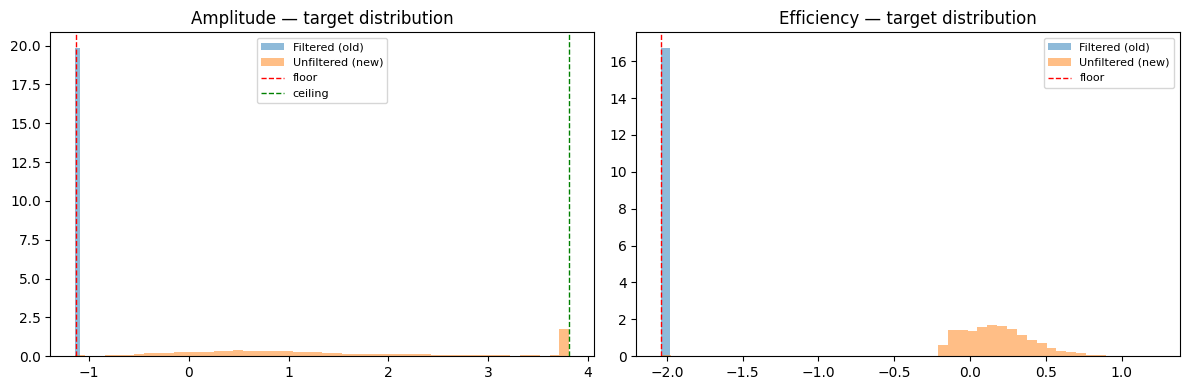


→ If 'UNFILTERED' Amplitude shows a new spike at the ceiling line, disabling the filter relocated the collapse rather than fixed it — in that case, swap TARGET_APPLY_BLINK_FILTER back to True and instead recalibrate GAP_THRESHOLD_MS for 30Hz (e.g. a percentile of this trial's own gap_ms distribution).


In [9]:
# ──────────────────────────────────────────────────────────────────────────
# BLOCK 5.5 — Validate the blink-filter change
# ──────────────────────────────────────────────────────────────────────────
print("\n--- Block 5.5: Blink-filter sensitivity check ---")

amp_floor_scaled   = (AMPLITUDE_FLOOR - scaler.mean_[3]) / scaler.scale_[3]
amp_ceiling_scaled = (AMPLITUDE_MAX   - scaler.mean_[3]) / scaler.scale_[3]
eff_zero_scaled    = (0.0 - scaler.mean_[5]) / scaler.scale_[5]
print(f"Amplitude floor (scaled)  : {amp_floor_scaled:.3f}")
print(f"Amplitude ceiling (scaled): {amp_ceiling_scaled:.3f}")
print(f"Efficiency-zero (scaled)  : {eff_zero_scaled:.3f}")

feats_filtered, feats_unfiltered, gap_fracs = [], [], []
for trial in target_trials_data:
    fdf = trial['fix_df']
    if len(fdf) < 2:
        continue
    gap_ms = fdf['onset_ms'] - (fdf['onset_ms'].shift(1) + fdf['duration_ms'].shift(1))
    gap_ms = gap_ms.dropna()
    if len(gap_ms) > 0:
        gap_fracs.append((gap_ms > GAP_THRESHOLD_MS).mean())
    feats_filtered.append(compute_fixation_features(fdf, scaler, apply_blink_filter=True))
    feats_unfiltered.append(compute_fixation_features(fdf, scaler, apply_blink_filter=False))

feats_filtered   = np.vstack(feats_filtered)
feats_unfiltered = np.vstack(feats_unfiltered)

print(f"\nFraction of inter-fixation gaps > GAP_THRESHOLD_MS ({GAP_THRESHOLD_MS}ms): "
      f"{np.mean(gap_fracs):.2%}  (= current blink_cross trigger rate)")

for name, idx, floor_v, ceil_v in [('Amplitude', 3, amp_floor_scaled, amp_ceiling_scaled),
                                     ('Efficiency', 5, eff_zero_scaled, None)]:
    f_filt, f_unfilt = feats_filtered[:, idx], feats_unfiltered[:, idx]
    print(f"\n{name}:")
    print(f"  FILTERED   — mean={f_filt.mean():.3f} std={f_filt.std():.3f} "
          f" frac@floor(±0.05)={(np.abs(f_filt - floor_v) < 0.05).mean():.2%}")
    msg = f"  UNFILTERED — mean={f_unfilt.mean():.3f} std={f_unfilt.std():.3f}"
    if ceil_v is not None:
        msg += f" frac@ceiling(±0.05)={(np.abs(f_unfilt - ceil_v) < 0.05).mean():.2%}"
    print(msg)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, idx, name, floor_v, ceil_v in [(axes[0], 3, 'Amplitude', amp_floor_scaled, amp_ceiling_scaled),
                                         (axes[1], 5, 'Efficiency', eff_zero_scaled, None)]:
    ax.hist(feats_filtered[:, idx],   bins=50, alpha=0.5, density=True, label='Filtered (old)')
    ax.hist(feats_unfiltered[:, idx], bins=50, alpha=0.5, density=True, label='Unfiltered (new)')
    ax.axvline(floor_v, color='red', linestyle='--', lw=1, label='floor')
    if ceil_v is not None:
        ax.axvline(ceil_v, color='green', linestyle='--', lw=1, label='ceiling')
    ax.set_title(f'{name} — target distribution')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\n→ If 'UNFILTERED' Amplitude shows a new spike at the ceiling line, "
      "disabling the filter relocated the collapse rather than fixed it — "
      "in that case, swap TARGET_APPLY_BLINK_FILTER back to True and instead "
      "recalibrate GAP_THRESHOLD_MS for 30Hz (e.g. a percentile of this "
      "trial's own gap_ms distribution).")

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5.6 — Fix Target Amplitude Collapse
# Calculates the 95th-percentile amplitude for 30Hz data and re-processes
# the target trials with the new ceiling and blink filter disabled.
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Block 5.6: Recalibrating Target Amplitude Ceiling ---")

# 1. Gather all raw (unscaled) amplitudes from unfiltered target data
raw_target_amplitudes = []
for trial in target_trials_data:
    fdf = trial['fix_df']
    if len(fdf) < 2:
        continue
    
    # Recompute raw amplitude for this trial
    prev_x = fdf['cx_norm'].shift(1)
    prev_y = fdf['cy_norm'].shift(1)
    raw_amp = np.sqrt((fdf['cx_norm'] - prev_x)**2 + (fdf['cy_norm'] - prev_y)**2)
    raw_amp = raw_amp.dropna()
    raw_target_amplitudes.extend(raw_amp.values)

raw_target_amplitudes = np.array(raw_target_amplitudes)

# 2. Calculate the 95th percentile for 30Hz data
NEW_AMPLITUDE_MAX = float(np.percentile(raw_target_amplitudes, 95))
print(f"Old AMPLITUDE_MAX (250Hz) : {AMPLITUDE_MAX:.6f}")
print(f"New AMPLITUDE_MAX (30Hz)  : {NEW_AMPLITUDE_MAX:.6f}")
print(f"Clipping reduction        : {(1 - NEW_AMPLITUDE_MAX/AMPLITUDE_MAX):.2%} less distortion")

# 3. Re-process all target trials using the new cap and NO blink filter
print("\nRe-engineering features with new ceiling and blink filter OFF ...")
for trial in tqdm(target_trials_data, desc="Re-processing trials"):
    fdf = trial['fix_df']
    
    # Temporarily override the global constant for the feature engineering function
    # We create a modified engineer_features call inline to use the new max
    fdf = fdf.copy().reset_index(drop=True)
    fdf['feat_duration'] = fdf['duration_ms'].astype(float)
    fdf['feat_x'] = fdf['cx_norm'].astype(float)
    fdf['feat_y'] = fdf['cy_norm'].astype(float)
    
    prev_x = fdf['feat_x'].shift(1)
    prev_y = fdf['feat_y'].shift(1)
    raw_amp = np.sqrt((fdf['feat_x'] - prev_x)**2 + (fdf['feat_y'] - prev_y)**2)
    raw_amp = raw_amp.fillna(0.0)
    
    # USE THE NEW CEILING HERE
    fdf['feat_amplitude'] = np.clip(raw_amp, AMPLITUDE_FLOOR, NEW_AMPLITUDE_MAX)
    fdf.loc[fdf.index[0], 'feat_amplitude'] = 0.0 
    
    # Blink filter OFF
    is_first = prev_x.isna()
    fdf['feat_regression'] = ((fdf['feat_x'] < prev_x) & ~is_first).astype(int)
    
    safe_amp = np.maximum(fdf['feat_amplitude'].values, AMPLITUDE_FLOOR)
    raw_log = np.log1p(fdf['feat_duration'].values / safe_amp)
    fdf['feat_efficiency'] = np.where(is_first, 0.0, np.clip(raw_log, 0.0, EFFICIENCY_CAP))
    
    feats_raw = fdf[FEATURE_COLS].values.astype(np.float32)
    feats_scaled = scaler.transform(feats_raw).astype(np.float32)
    
    seqs = []
    n = len(feats_scaled)
    for start in range(0, n - SEQUENCE_LENGTH + 1, STEP):
        seqs.append(feats_scaled[start : start + SEQUENCE_LENGTH])
        
    trial['seqs'] = np.array(seqs, dtype=np.float32) if seqs else np.array([])

# 4. Verify the fix
print("\nVerifying new feature distributions (should NOT be at ceiling) ...")
check_amps = []
for trial in target_trials_data:
    if len(trial['seqs']) > 0:
        # Extract the amplitude column (index 3) from the sequences
        check_amps.append(trial['seqs'][:, :, 3].ravel())
        
check_amps = np.concatenate(check_amps)
new_ceiling_scaled = (NEW_AMPLITUDE_MAX - scaler.mean_[3]) / scaler.scale_[3]
frac_at_ceiling = (np.abs(check_amps - new_ceiling_scaled) < 0.05).mean()

print(f"Fraction of amplitudes at NEW ceiling: {frac_at_ceiling:.2%}")
print(f"Target amplitude mean (scaled): {check_amps.mean():.3f} | std: {check_amps.std():.3f}")

if frac_at_ceiling < 0.10:
    print("✅ Ceiling collapse resolved! Amplitude feature is now healthy.")
else:
    print("⚠️ Warning: Amplitudes are still clustering at the new ceiling.")

# Update global constant so Block 6 uses the new sequences
# (The sequences are already updated in target_trials_data, so Block 6 needs no changes)


--- Block 5.6: Recalibrating Target Amplitude Ceiling ---
Old AMPLITUDE_MAX (250Hz) : 0.076948
New AMPLITUDE_MAX (30Hz)  : 0.235633
Clipping reduction        : -206.22% less distortion

Re-engineering features with new ceiling and blink filter OFF ...


Re-processing trials:   0%|          | 0/33 [00:00<?, ?it/s]


Verifying new feature distributions (should NOT be at ceiling) ...
Fraction of amplitudes at NEW ceiling: 4.94%
Target amplitude mean (scaled): 2.266 | std: 3.446
✅ Ceiling collapse resolved! Amplitude feature is now healthy.


# BLOCK 6 — Build Target Tensors with Padding & Validity Masks
# Use SOURCE_MAX_LEN (137) so tensors are compatible with the source model.
# Participants with more than 137 sequences are truncated (keep first 137).

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 — Build Target Tensors with Padding & Validity Masks
# Use SOURCE_MAX_LEN (137) so tensors are compatible with the source model.
# Trials with more than 137 sequences are truncated (keep first 137).
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Block 6: Building Target Tensors (Trial-Level) ---")

n_exceed = sum(1 for t in target_trials_data if len(t['seqs']) > SOURCE_MAX_LEN)
print(f"Target trials exceeding SOURCE_MAX_LEN={SOURCE_MAX_LEN}: {n_exceed}")

X_tgt_list   = []
mask_tgt_list = []
pid_tgt_list  = []   # Keeping track of which PID owns which trial

for trial_info in target_trials_data:
    seqs = trial_info['seqs']
    n = len(seqs)
    
    padded   = np.zeros((SOURCE_MAX_LEN, SEQUENCE_LENGTH, N_FEATURES), dtype=np.float32)
    mask_vec = np.zeros(SOURCE_MAX_LEN, dtype=np.float32)
    
    copy_n = min(n, SOURCE_MAX_LEN)
    padded[:copy_n]   = seqs[:copy_n]
    mask_vec[:copy_n] = 1.0
    
    X_tgt_list.append(padded)
    mask_tgt_list.append(mask_vec)
    pid_tgt_list.append(trial_info['pid'])

# Shape is now (N_valid_trials, 137, 20, 6) instead of (N_participants, ...)
X_tgt    = np.array(X_tgt_list, dtype=np.float32)
mask_tgt = np.array(mask_tgt_list, dtype=np.float32)
pid_tgt  = np.array(pid_tgt_list)

print(f"X_tgt shape    : {X_tgt.shape}")
print(f"mask_tgt shape : {mask_tgt.shape}")

real_data_frac = mask_tgt.mean(axis=1)
print(f"Real-data fraction per trial: "
      f"mean={real_data_frac.mean():.2%} min={real_data_frac.min():.2%}")


--- Block 6: Building Target Tensors (Trial-Level) ---
Target trials exceeding SOURCE_MAX_LEN=40: 6
X_tgt shape    : (33, 40, 20, 6)
mask_tgt shape : (33, 40)
Real-data fraction per trial: mean=72.95% min=35.00%


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6.5 — Accepted Trial Sequence Count Summary
# Displays the number of sequences generated for each successfully
# processed trial file before padding/truncation occurred in Block 6.
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Block 6.5: Accepted Trial Sequence Counts ---")

if 'meta_df' not in locals() or meta_df.empty:
    print("⚠️ meta_df is empty or not found. Please ensure Block 5 has run successfully.")
else:
    total_seqs = meta_df['n_seqs'].sum()
    print(f"Total accepted trials: {len(meta_df)}")
    print(f"Total sequences generated: {total_seqs}")
    print(f"(Note: Block 6 truncates trials exceeding {SOURCE_MAX_LEN} sequences)\n")
    
    # Print formatted table
    print(f"{'Trial Name':<50} | {'Sequences':>9}")
    print("─" * 65)
    
    for idx, row in meta_df.iterrows():
        trial_name = row['trial_name']
        n_seqs = row['n_seqs']
        
        # Flag trials that will be truncated in Block 6
        flag = " ⚠️ TRUNCATED" if n_seqs > SOURCE_MAX_LEN else ""
        print(f"{trial_name:<50} | {n_seqs:>9}{flag}")
        
    print("─" * 65)
    print(f"{'TOTAL':<50} | {total_seqs:>9}")
    print(f"\nMean sequences per trial  : {meta_df['n_seqs'].mean():.1f}")
    print(f"Median sequences per trial: {meta_df['n_seqs'].median():.1f}")
    print(f"Max sequences per trial   : {meta_df['n_seqs'].max()}")
    print(f"Min sequences per trial   : {meta_df['n_seqs'].min()}")


--- Block 6.5: Accepted Trial Sequence Counts ---
Total accepted trials: 33
Total sequences generated: 1003
(Note: Block 6 truncates trials exceeding 40 sequences)

Trial Name                                         | Sequences
─────────────────────────────────────────────────────────────────
gaze_paragraph (1).csv                             |        31
gaze_paragraph (2).csv                             |        15
gaze_paragraph (3).csv                             |        17
gaze_paragraph (4).csv                             |        14
gaze_paragraph (5).csv                             |        53 ⚠️ TRUNCATED
gaze_paragraph (6).csv                             |        41 ⚠️ TRUNCATED
gaze_paragraph (7).csv                             |        15
gaze_paragraph.csv                                 |        36
raw-gaze-webcam (1).csv                            |        38
raw-gaze-webcam (1)0.csv                           |        25
raw-gaze-webcam (1)1.csv                         

# BLOCK 7 — Domain Gap Visualisation (BEFORE Adaptation)
#
# We extract participant-level embeddings using the FROZEN Phase-2 encoder,
# then visualise the domain gap with:
   7a. t-SNE of source vs target embeddings
   7b. Per-feature distribution comparison (source vs target)
   7c. Statistical tests (KS, Mann-Whitney U) per feature
   7d. Sequence count & filter rate analysis


--- Block 7: Domain Gap Visualisation (Before Adaptation) ---
Computing pre-adaptation embeddings …


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7e8842524720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


Source embeddings : (70, 64)
Target embeddings : (33, 64)
Running t-SNE …
Source fixation-steps for analysis: 42,680
Target fixation-steps for analysis: 19,260

Per-feature domain gap statistical tests:
  Duration        KS=0.331 ***  Δmean=1.2588
  X               KS=0.151 ***  Δmean=0.0850
  Y (raw)         KS=0.097 ***  Δmean=0.1142
  Amplitude       KS=0.400 ***  Δmean=2.2240
  Regression      KS=0.006      Δmean=0.0119
  Efficiency      KS=0.302 ***  Δmean=0.1844


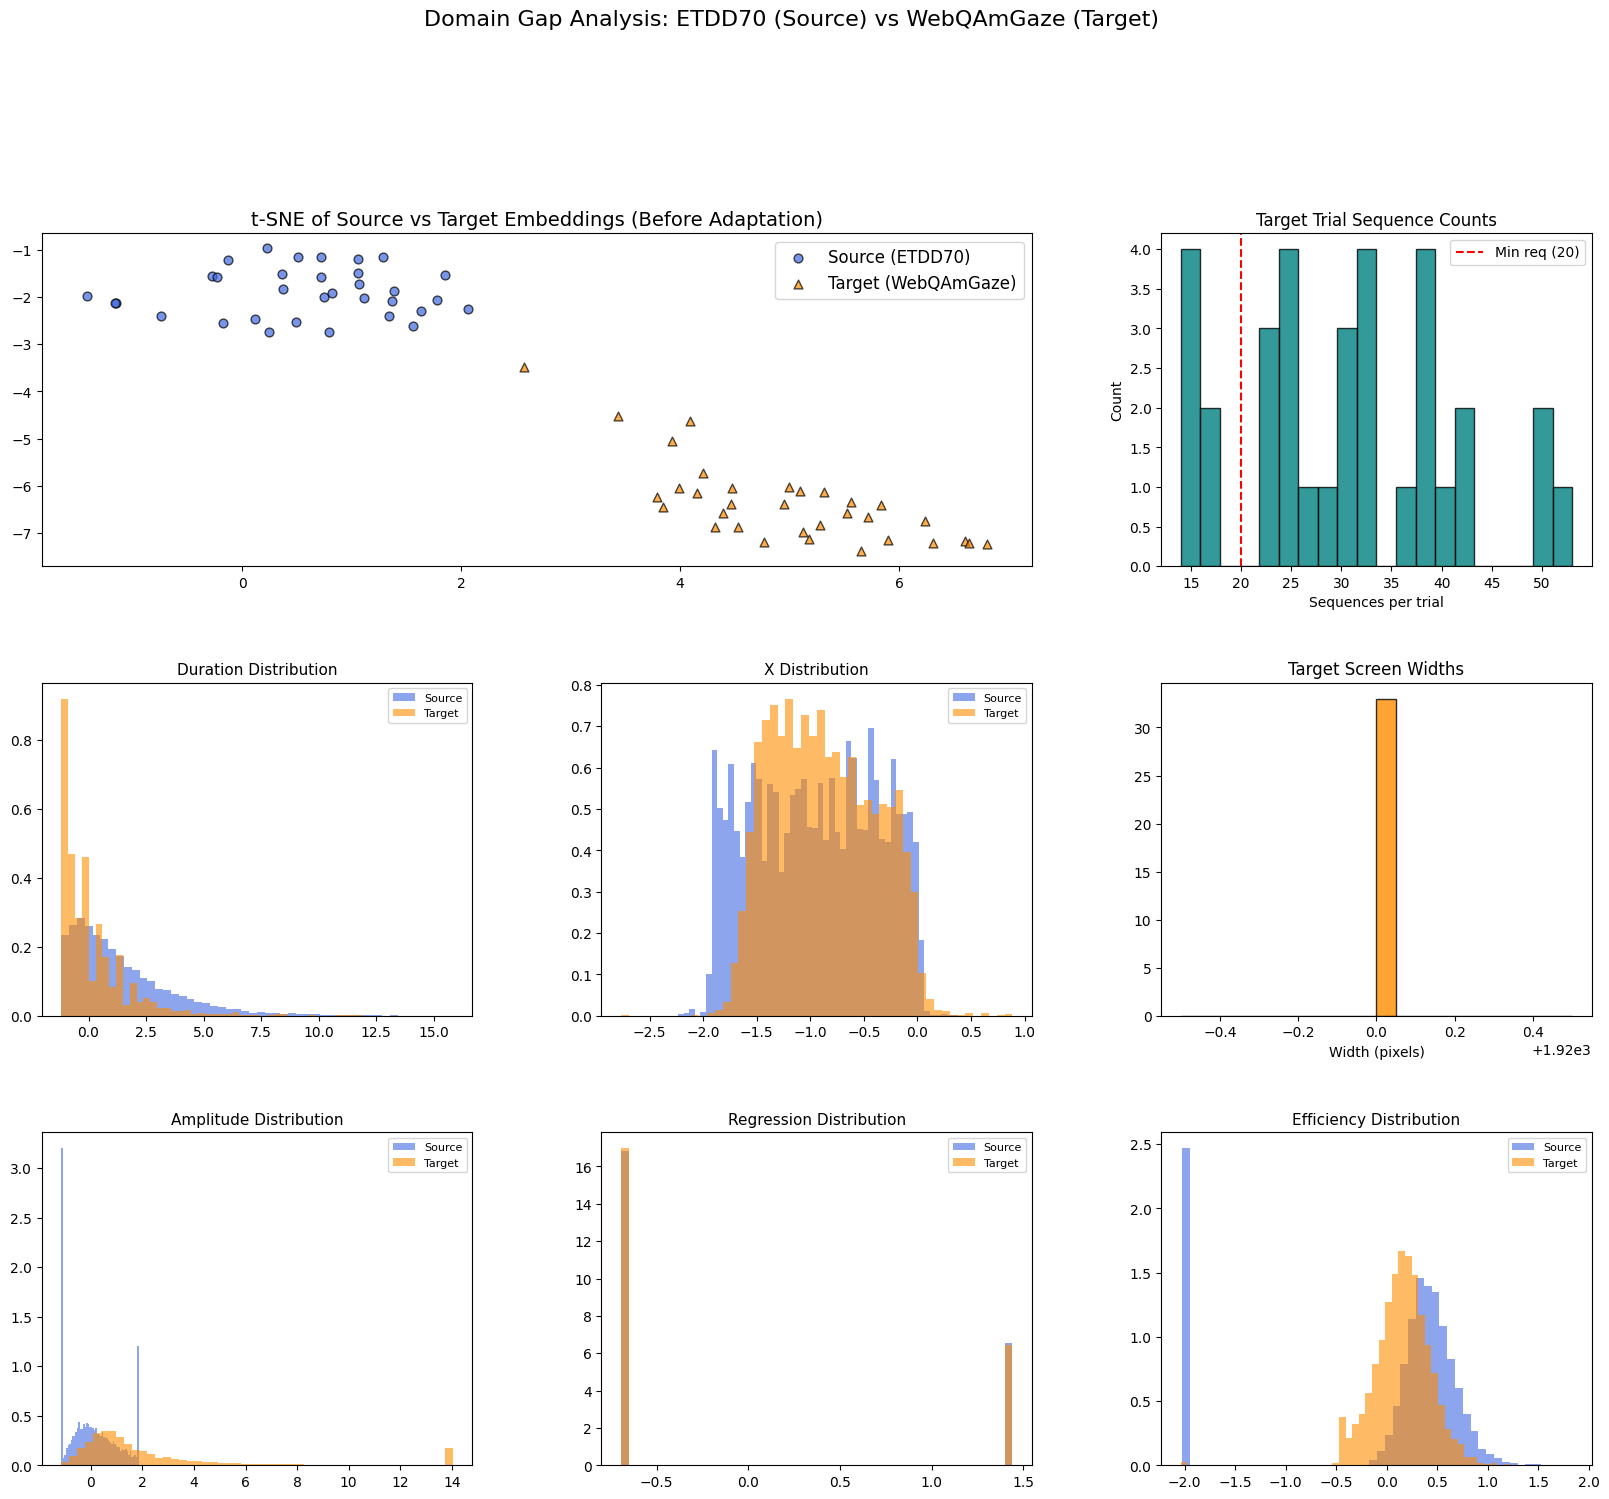

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 7 — Domain Gap Visualisation (BEFORE Adaptation)
# We extract sample-level embeddings using the FROZEN Phase-2 encoder,
# then visualise the domain gap with:
# 7a. t-SNE of source vs target embeddings
# 7b. Per-feature distribution comparison (source vs target)
# 7c. Statistical tests (KS, Mann-Whitney U) per feature
# 7d. Sequence count & filter rate analysis
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Block 7: Domain Gap Visualisation (Before Adaptation) ---")

class MaskedGlobalAvgPool(tf.keras.layers.Layer):
    """Identical to Phase-2 — excludes padded slots from the average."""
    def call(self, embeddings, mask):
        mask_exp = tf.expand_dims(mask, -1)
        masked = embeddings * mask_exp
        sum_emb = tf.reduce_sum(masked, axis=1)
        count = tf.reduce_sum(mask_exp, axis=1) + EPSILON
        return sum_emb / count

def get_sample_embeddings(X: np.ndarray,
                          mask: np.ndarray,
                          encoder_model: tf.keras.Model,
                          batch_size: int = 16) -> np.ndarray:
    """
    X : (N_samples, max_len, 20, 6)
    mask : (N_samples, max_len)
    Returns sample-level embeddings (N_samples, 64).
    """
    pool_layer = MaskedGlobalAvgPool()
    results = []
    td_encoder = TimeDistributed(encoder_model)
    n = len(X)
    
    for start in range(0, n, batch_size):
        xb = tf.constant(X[start : start + batch_size])
        mb = tf.constant(mask[start : start + batch_size])
        enc = td_encoder(xb, training=False) # (B, max_len, 64)
        emb = pool_layer(enc, mb)             # (B, 64)
        results.append(emb.numpy())
        
    return np.vstack(results)

print("Computing pre-adaptation embeddings …")
emb_src_train = get_sample_embeddings(X_src_train, mask_src_train, encoder_frozen)
emb_src_val   = get_sample_embeddings(X_src_val, mask_src_val, encoder_frozen)
emb_src_all   = np.vstack([emb_src_train, emb_src_val])

emb_tgt_all   = get_sample_embeddings(X_tgt, mask_tgt, encoder_frozen)

print(f"Source embeddings : {emb_src_all.shape}")
print(f"Target embeddings : {emb_tgt_all.shape}")

# ── 7a. t-SNE ─────────────────────────────────────────────────────────────────
print("Running t-SNE …")
N_VIZ = min(len(emb_src_all), len(emb_tgt_all), 300)
rng = np.random.default_rng(42)
src_idx = rng.choice(len(emb_src_all), N_VIZ, replace=False)
tgt_idx = rng.choice(len(emb_tgt_all), N_VIZ, replace=False)

combined_emb = np.vstack([emb_src_all[src_idx], emb_tgt_all[tgt_idx]])
combined_labels = np.array(['Source (ETDD70)'] * N_VIZ + ['Target (WebQAmGaze)'] * N_VIZ)

tsne = TSNE(n_components=2, perplexity=min(30, N_VIZ-1), max_iter=1000, random_state=42, verbose=0)
tsne_coords = tsne.fit_transform(combined_emb)

# ── 7b. Feature distributions ─────────────────────────────────────────────────
def unpad_features(X: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Return (M, 20, 6) where M = sum of real slots; then reshape to (M*20, 6)."""
    rows = []
    for i in range(len(X)):
        real_n = int(mask[i].sum())
        if real_n > 0:
            rows.append(X[i, :real_n].reshape(-1, N_FEATURES))
    return np.vstack(rows) if rows else np.zeros((0, N_FEATURES))

src_feats = unpad_features(X_src_train, mask_src_train)
tgt_feats = unpad_features(X_tgt, mask_tgt)
print(f"Source fixation-steps for analysis: {len(src_feats):,}")
print(f"Target fixation-steps for analysis: {len(tgt_feats):,}")

# ── 7c. Statistical tests ─────────────────────────────────────────────────────
print("\nPer-feature domain gap statistical tests:")
feat_labels = ['Duration', 'X', 'Y (raw)', 'Amplitude', 'Regression', 'Efficiency']
stat_results = []

for i, fname in enumerate(feat_labels):
    src_f = src_feats[:, i]
    tgt_f = tgt_feats[:, i]
    ks_stat, ks_p = ks_2samp(src_f, tgt_f)
    mw_stat, mw_p = mannwhitneyu(src_f, tgt_f, alternative='two-sided')
    stat_results.append({
        'Feature'  : fname,
        'Src mean' : round(src_f.mean(), 4),
        'Tgt mean' : round(tgt_f.mean(), 4),
        'Mean diff': round(abs(src_f.mean() - tgt_f.mean()), 4),
        'KS stat'  : round(ks_stat, 4),
        'KS p'     : f"{ks_p:.2e}",
        'MW p'     : f"{mw_p:.2e}",
    })
    sig = "***" if ks_p < 0.001 else "**" if ks_p < 0.01 else "*" if ks_p < 0.05 else ""
    print(f"  {fname:15s} KS={ks_stat:.3f} {sig:3s}  Δmean={abs(src_f.mean() - tgt_f.mean()):.4f}")

# ── 7d. Plotting ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

# t-SNE Plot
ax_tsne = fig.add_subplot(gs[0, :2])
for label, color, marker in [('Source (ETDD70)', 'royalblue', 'o'), 
                              ('Target (WebQAmGaze)', 'darkorange', '^')]:
    idx = combined_labels == label
    ax_tsne.scatter(tsne_coords[idx, 0], tsne_coords[idx, 1], 
                    c=color, label=label, alpha=0.7, marker=marker, edgecolors='k', s=40)
ax_tsne.set_title('t-SNE of Source vs Target Embeddings (Before Adaptation)', fontsize=14)
ax_tsne.legend(fontsize=12)

# Sequence count histogram
ax_seq = fig.add_subplot(gs[0, 2])
if not meta_df.empty:
    ax_seq.hist(meta_df['n_seqs'], bins=20, color='teal', edgecolor='black', alpha=0.8)
    ax_seq.axvline(SEQUENCE_LENGTH, color='red', linestyle='--', label=f'Min req ({SEQUENCE_LENGTH})')
    ax_seq.set_title('Target Trial Sequence Counts', fontsize=12)
    ax_seq.set_xlabel('Sequences per trial')
    ax_seq.set_ylabel('Count')
    ax_seq.legend()

# Screen resolution plot (Handles the KeyError if meta_df lacks the columns)
ax_res = fig.add_subplot(gs[1, 2])
if not meta_df.empty and 'screen_w' in meta_df.columns:
    ax_res.hist(meta_df['screen_w'], bins=20, color='darkorange', edgecolor='black', alpha=0.8)
    ax_res.set_title('Target Screen Widths', fontsize=12)
    ax_res.set_xlabel('Width (pixels)')
else:
    ax_res.text(0.5, 0.5, 'Screen width data\nnot in meta_df', 
                ha='center', va='center', fontsize=12)
    ax_res.set_title('Target Screen Widths (Missing)', fontsize=12)

# Feature distribution plots (first 6 features)
for i, fname in enumerate(feat_labels):
    row = 1 + (i // 3)
    col = i % 3
    if row == 1 and col == 2: 
        continue  # Skip the screen res slot
    
    ax_feat = fig.add_subplot(gs[row, col])
    ax_feat.hist(src_feats[:, i], bins=50, density=True, alpha=0.6, 
                 color='royalblue', label='Source')
    ax_feat.hist(tgt_feats[:, i], bins=50, density=True, alpha=0.6, 
                 color='darkorange', label='Target')
    ax_feat.set_title(f'{fname} Distribution', fontsize=11)
    ax_feat.legend(fontsize=8)

plt.suptitle('Domain Gap Analysis: ETDD70 (Source) vs WebQAmGaze (Target)', fontsize=16, y=1.02)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 — MMD Loss Implementation
#
# Multi-kernel Maximum Mean Discrepancy:
#   MMD²(S,T) = E[k(s,s')] + E[k(t,t')] - 2·E[k(s,t)]
#
# Kernel: sum of RBF kernels at multiple bandwidths
#   k(x,y) = Σ_σ  exp( -‖x-y‖² / (2σ²) )
#
# Bandwidth grid: median heuristic × {0.5, 1, 2, 5}
#   The median heuristic ensures σ adapts to the actual embedding scale,
#   so the kernel is neither too narrow (misses global structure)
#   nor too wide (loses local discriminability).
#
# Unbiased estimator: diagonal of same-set gram matrices is zeroed out
#   to remove the trivial self-similarity terms.
# ─────────────────────────────────────────────────────────────────────────────

In [14]:
print("\n--- Block 8: MMD Loss (adaptive bandwidth + stability fixes) ---")

def pairwise_sq_distances(A: tf.Tensor, B: tf.Tensor) -> tf.Tensor:
    A2 = tf.reduce_sum(tf.square(A), axis=1, keepdims=True)
    B2 = tf.reduce_sum(tf.square(B), axis=1, keepdims=True)
    AB = tf.matmul(A, B, transpose_b=True)
    return A2 + tf.transpose(B2) - 2.0 * AB

def rbf_kernel(dist_sq: tf.Tensor, sigma_sq: tf.Tensor) -> tf.Tensor:
    return tf.exp(-dist_sq / (2.0 * sigma_sq + EPSILON))

def mmd_loss(source_emb: tf.Tensor,
             target_emb: tf.Tensor,
             bandwidth_multipliers=(0.25, 0.5, 1.0, 2.0, 4.0)) -> tf.Tensor:
    """Unbiased multi-kernel MMD^2, median-heuristic bandwidths, clamped >= 0."""
    n = tf.cast(tf.shape(source_emb)[0], tf.float32)
    m = tf.cast(tf.shape(target_emb)[0], tf.float32)

    dxx = tf.maximum(pairwise_sq_distances(source_emb, source_emb), 1e-8)
    dyy = tf.maximum(pairwise_sq_distances(target_emb, target_emb), 1e-8)
    dxy = tf.maximum(pairwise_sq_distances(source_emb, target_emb), 1e-8)

    all_dists = tf.concat([tf.reshape(dxx, [-1]), tf.reshape(dyy, [-1])], axis=0)
    sorted_d = tf.sort(all_dists)
    n_d = tf.cast(tf.shape(sorted_d)[0], tf.float32)
    mid_slice = sorted_d[tf.cast(n_d * 0.4, tf.int32):tf.cast(n_d * 0.6, tf.int32)]
    sigma_med = tf.reduce_mean(mid_slice) + EPSILON

    mmd2 = tf.constant(0.0, dtype=tf.float32)
    for mult in bandwidth_multipliers:
        sigma_sq = sigma_med * mult
        Kxx = rbf_kernel(dxx, sigma_sq)
        Kyy = rbf_kernel(dyy, sigma_sq)
        Kxy = rbf_kernel(dxy, sigma_sq)
        Kxx = tf.linalg.set_diag(Kxx, tf.zeros(tf.shape(Kxx)[0]))
        Kyy = tf.linalg.set_diag(Kyy, tf.zeros(tf.shape(Kyy)[0]))
        term_xx = tf.reduce_sum(Kxx) / (n * (n - 1.0) + EPSILON)
        term_yy = tf.reduce_sum(Kyy) / (m * (m - 1.0) + EPSILON)
        term_xy = tf.reduce_mean(Kxy)
        mmd2 += term_xx + term_yy - 2.0 * term_xy

    return tf.maximum(mmd2 / float(len(bandwidth_multipliers)), 0.0)

# Sanity check
tf.random.set_seed(0)
s_test = tf.random.normal([16, 64])
t_test = tf.random.normal([16, 64]) + 3.0
t_same = tf.random.normal([16, 64])
mmd_large = mmd_loss(s_test, t_test).numpy()
mmd_small = mmd_loss(s_test, t_same).numpy()
print(f"MMD sanity — different distributions: {mmd_large:.4f} (expect > 0)")
print(f"MMD sanity — same distributions     : {mmd_small:.4f} (expect ≈ 0)")
assert mmd_large > mmd_small, "MMD sanity check failed!"
print("MMD implementation verified ✓")


--- Block 8: MMD Loss (adaptive bandwidth + stability fixes) ---
MMD sanity — different distributions: 0.7583 (expect > 0)
MMD sanity — same distributions     : 0.0073 (expect ≈ 0)
MMD implementation verified ✓


In [15]:
# ──────────────────────────────────────────────────────────────────────────
# BLOCK 8.5 — Adaptive-bandwidth sanity check on real embeddings
# ──────────────────────────────────────────────────────────────────────────
print("\n--- Block 8.5: Adaptive-bandwidth sanity check ---")

dxx_chk = tf.maximum(pairwise_sq_distances(
    tf.constant(emb_src_all, dtype=tf.float32), tf.constant(emb_src_all, dtype=tf.float32)), 1e-8)
dyy_chk = tf.maximum(pairwise_sq_distances(
    tf.constant(emb_tgt_all, dtype=tf.float32), tf.constant(emb_tgt_all, dtype=tf.float32)), 1e-8)
all_d_chk = tf.concat([tf.reshape(dxx_chk, [-1]), tf.reshape(dyy_chk, [-1])], axis=0)
sorted_chk = tf.sort(all_d_chk)
n_chk = tf.cast(tf.shape(sorted_chk)[0], tf.float32)
mid_chk = sorted_chk[tf.cast(n_chk*0.4, tf.int32):tf.cast(n_chk*0.6, tf.int32)]
sigma_med_chk = float(tf.reduce_mean(mid_chk))

print(f"Median pairwise sq-distance (sigma_med): {sigma_med_chk:.3f}")
print(f"Bandwidth grid (sigma^2)               : "
      f"{[round(sigma_med_chk*m, 3) for m in (0.25, 0.5, 1.0, 2.0, 4.0)]}")

mmd_real = float(mmd_loss(tf.constant(emb_src_all, dtype=tf.float32),
                           tf.constant(emb_tgt_all, dtype=tf.float32)))
print(f"MMD^2 (adaptive, real embeddings, post Block-5 fix): {mmd_real:.4f}")
print("Compare this to class_loss (~0.6-0.7 at start). If λ·MMD ends up "
      "orders of magnitude larger/smaller than class_loss during the ramp, "
      "LAMBDA_MMD_FINAL (currently 0.1) may need adjusting.")


--- Block 8.5: Adaptive-bandwidth sanity check ---
Median pairwise sq-distance (sigma_med): 0.154
Bandwidth grid (sigma^2)               : [0.038, 0.077, 0.154, 0.307, 0.614]
MMD^2 (adaptive, real embeddings, post Block-5 fix): 0.6417
Compare this to class_loss (~0.6-0.7 at start). If λ·MMD ends up orders of magnitude larger/smaller than class_loss during the ramp, LAMBDA_MMD_FINAL (currently 0.1) may need adjusting.


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 9 — Build Adaptive UDA Model
#
# The UDA model re-uses the Phase-2 architecture but:
#   1. The encoder is UNFROZEN — it adapts during UDA training
#   2. A lightweight domain discriminator is built for MONITORING ONLY
#      (not used in the loss — we use MMD instead)
#   3. An embedding extractor sub-model is exposed for MMD computation
#
# Two separate Keras models:
#   uda_classifier   — full model: input → embedding → class prediction
#   embedding_model  — input → (64,) embedding (for MMD computation)
# ─────────────────────────────────────────────────────────────────────────────

In [16]:
print("\n--- Block 9: Building UDA Model ---")

@keras.saving.register_keras_serializable()
class MaskedGlobalAvgPoolV2(keras.layers.Layer):
    def call(self, inputs):
        x, mask_tensor = inputs
        mask_f = tf.cast(mask_tensor, x.dtype)
        mask_f = tf.expand_dims(mask_f, axis=-1)
        masked_sum = tf.reduce_sum(x * mask_f, axis=1)
        valid_count = tf.reduce_sum(mask_f, axis=1)
        return masked_sum / tf.maximum(valid_count, 1e-6)

    def compute_output_shape(self, input_shape):
        x_shape = input_shape[0]
        return (x_shape[0], x_shape[2])


def build_uda_models(source_classifier: tf.keras.Model, max_len: int = SOURCE_MAX_LEN):
    td_layer = source_classifier.get_layer('shared_gaze_encoder')
    inner_encoder = td_layer.layer

    # Explicit per-layer freeze config for UDA — see review notes:
    #   encoder_lstm_1    : frozen (unchanged, 69,120 params)
    #   encoder_mhsa      : frozen (NEW — was trainable, ~33,088 params)
    #   encoder_layernorm : frozen (NEW — was trainable, 256 params)
    #   encoder_lstm_2    : trainable (49,408 params — MMD's lever on the embedding)
    for layer in inner_encoder.layers:
        if layer.name == 'encoder_lstm_1':
            layer.trainable = False
        elif layer.name in ('encoder_mhsa', 'encoder_layernorm'):
            layer.trainable = False
        elif layer.name == 'encoder_lstm_2':
            layer.trainable = True

    input_seq = Input(shape=(max_len, SEQUENCE_LENGTH, N_FEATURES), name='input_meaningful')
    input_mask = Input(shape=(max_len,), dtype=tf.float32, name='mask_meaningful')
    encoded = TimeDistributed(inner_encoder, name='shared_gaze_encoder')(input_seq)
    embedding = MaskedGlobalAvgPoolV2(name='masked_avg_pool')([encoded, input_mask])

    head_dense_1 = source_classifier.get_layer('head_dense_1')
    head_drop_1  = source_classifier.get_layer('head_dropout_1')
    head_dense_2 = source_classifier.get_layer('head_dense_2')
    head_drop_2  = source_classifier.get_layer('head_dropout_2')
    head_out     = source_classifier.get_layer('output_classifier')

    x = head_dense_1(embedding)
    x = head_drop_1(x)
    x = head_dense_2(x)
    x = head_drop_2(x)
    output = head_out(x)

    uda_classifier  = Model(inputs=[input_seq, input_mask], outputs=output, name='uda_classifier')
    embedding_model = Model(inputs=[input_seq, input_mask], outputs=embedding, name='embedding_model')

    disc_input = Input(shape=(LATENT_DIM,), name='disc_input')
    d = Dense(32, name='disc_d1')(disc_input)
    d = LayerNormalization()(d)
    d = tf.keras.layers.ReLU()(d)
    d = Dropout(0.2)(d)
    d = Dense(1, activation='sigmoid', name='disc_output')(d)
    discriminator = Model(disc_input, d, name='domain_discriminator')

    return uda_classifier, embedding_model, discriminator


uda_classifier, embedding_model, discriminator = build_uda_models(source_classifier)
discriminator.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                       loss='binary_crossentropy', metrics=['accuracy'])

# Split trainable vars: encoder-side gets the smaller LR, head-side keeps LR_INITIAL.
# (Substring match on 'encoder' — verified in Block 9.5.)
encoder_vars = [v for v in uda_classifier.trainable_variables if 'encoder' in v.name]
head_vars    = [v for v in uda_classifier.trainable_variables if 'encoder' not in v.name]
all_uda_vars = encoder_vars + head_vars

print("\nUDA Classifier summary:")
uda_classifier.summary(line_length=80)


--- Block 9: Building UDA Model ---

UDA Classifier summary:


Model: "uda_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_meaningful      │ (None, 40, 20, 6) │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ shared_gaze_encoder   │ (None, 40, 64)    │     151,872 │ input_meaningful[… │
│ (TimeDistributed)     │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ mask_meaningful       │ (None, 40)        │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ masked_avg_pool       │ (None, 64)        │           0 │ shared_gaze_encod… │
│ (MaskedGlobalAvgPool… │                   │             │ mask_meaningful[0… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ head_dense_1 (Dense)  │ (None, 64)        │       4,160 │ masked_avg_pool[0… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ head_dropout_1        │ (None, 64)        │           0 │ head_dense_1[1][0] │
│ (Dropout)             │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ head_dense_2 (Dense)  │ (None, 32)        │       2,080 │ head_dropout_1[1]… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ head_dropout_2        │ (None, 32)        │           0 │ head_dense_2[1][0] │
│ (Dropout)             │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ output_classifier     │ (None, 1)         │          33 │ head_dropout_2[1]… │
│ (Dense)               │                   │             │                    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 158,145 (617.75 KB)

 Trainable params: 55,681 (217.50 KB)

 Non-trainable params: 102,464 (400.25 KB)

In [17]:
# ──────────────────────────────────────────────────────────────────────────
# BLOCK 9.5 — Trainable-variable audit
# ──────────────────────────────────────────────────────────────────────────
print("\n--- Block 9.5: Trainable-variable audit ---")
print("Encoder-side trainable vars (LR = LR_INITIAL * 0.1):")
for v in encoder_vars:
    print(f"  {v.name:45s} {str(v.shape):>12s}  {int(np.prod(v.shape)):>8,}")

print("\nHead-side trainable vars (LR = LR_INITIAL):")
for v in head_vars:
    print(f"  {v.name:45s} {str(v.shape):>12s}  {int(np.prod(v.shape)):>8,}")

n_enc   = sum(int(np.prod(v.shape)) for v in encoder_vars)
n_head  = sum(int(np.prod(v.shape)) for v in head_vars)
n_total = n_enc + n_head
print(f"\nTotal trainable: {n_total:,}  (encoder: {n_enc:,} / head: {n_head:,})")
print(f"vs. previous run's 89,025 — reduction of {100*(1 - n_total/89025):.1f}%")


--- Block 9.5: Trainable-variable audit ---
Encoder-side trainable vars (LR = LR_INITIAL * 0.1):

Head-side trainable vars (LR = LR_INITIAL):
  kernel                                          (128, 256)    32,768
  recurrent_kernel                                 (64, 256)    16,384
  bias                                                (256,)       256
  kernel                                            (64, 64)     4,096
  bias                                                 (64,)        64
  kernel                                            (64, 32)     2,048
  bias                                                 (32,)        32
  kernel                                             (32, 1)        32
  bias                                                  (1,)         1

Total trainable: 55,681  (encoder: 0 / head: 55,681)
vs. previous run's 89,025 — reduction of 37.5%


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 10 — Custom Training Loop
#
# Per step:
#   SOURCE batch  (X_src, mask_src, y_src):
#     → classification loss (BCE)
#     → source embedding   for MMD
#
#   TARGET batch  (X_tgt, mask_tgt):
#     → target embedding for MMD
#
#   TOTAL LOSS = BCE_loss  +  λ(epoch) · MMD²(source_emb, target_emb)
#
#   λ schedule: linear ramp from 0 → LAMBDA_MMD_FINAL over LAMBDA_RAMP_EPOCHS
#     This lets the classifier stabilise before MMD pushes the encoder.
#
#   DISCRIMINATOR (monitoring only):
#     Updated independently each step to track how separable domains are.
#     D_acc ≈ 0.5 means perfect domain confusion (ideal outcome).
# ─────────────────────────────────────────────────────────────────────────────

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 10 — The Definitive UDA Training Run
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Block 10: Definitive UDA Training (MMD-Driven Convergence) ---")

# ═══════════════════════════════════════════════════════════════════════════════
# 1. PRISTINE INITIALIZATION (Guards against state leakage from previous runs)
# ═══════════════════════════════════════════════════════════════════════════════
print("Re-initializing models and optimizers from pristine Phase-2 weights...")
# FIX: Unpack only the 3 models returned by build_uda_models
uda_classifier, embedding_model, discriminator = build_uda_models(source_classifier)
discriminator.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])

# Re-split variables
encoder_vars = [v for v in uda_classifier.trainable_variables if 'encoder' in v.name]
head_vars    = [v for v in uda_classifier.trainable_variables if 'encoder' not in v.name]
for layer in uda_classifier.layers:
    lv = list(layer.trainable_variables)
    if not lv: continue
    if layer.name in ('shared_gaze_encoder', 'masked_avg_pool'): encoder_vars.extend(lv)
    else: head_vars.extend(lv)
all_uda_vars = encoder_vars + head_vars
print(f"  Trainable vars: encoder={len(encoder_vars)} | head={len(head_vars)}")

# Fresh Optimizers
uda_optimiser_encoder = tf.keras.optimizers.Adam(LR_INITIAL * 0.1)
uda_optimiser_head    = tf.keras.optimizers.Adam(LR_INITIAL)
disc_optimiser        = tf.keras.optimizers.Adam(1e-3)

# ═══════════════════════════════════════════════════════════════════════════════
# 2. SCHEDULE & CONSTANTS
# ═══════════════════════════════════════════════════════════════════════════════
MAX_LAMBDA = 0.4       # Proven safe maximum (1.0 causes forgetting)
RAMP_EPOCHS = 20       # Ramp up lambda over 20 epochs
MAX_EPOCHS = 500       # Let it run until MMD naturally plateaus
MMD_PATIENCE = 30      # Stop if MMD hasn't improved for 20 epochs
CLS_FORGET_LIMIT = 0.9 # Emergency brake if classification collapses

def lambda_schedule(epoch):
    if epoch >= RAMP_EPOCHS: return MAX_LAMBDA
    return MAX_LAMBDA * (epoch / RAMP_EPOCHS)

# ═══════════════════════════════════════════════════════════════════════════════
# 3. METRICS & DATA
# ═══════════════════════════════════════════════════════════════════════════════
bce_loss_fn = tf.keras.losses.BinaryCrossentropy()
train_loss_tracker = tf.keras.metrics.Mean(name='total_loss')
class_loss_tracker = tf.keras.metrics.Mean(name='class_loss')
mmd_loss_tracker   = tf.keras.metrics.Mean(name='mmd_loss')
val_auc_tracker    = tf.keras.metrics.AUC(name='val_auc')

src_train_ds = tf.data.Dataset.from_tensor_slices((X_src_train, mask_src_train, y_src_train)).shuffle(len(y_src_train), seed=42).batch(BATCH_SIZE_SOURCE).prefetch(tf.data.AUTOTUNE).repeat()
tgt_ds = tf.data.Dataset.from_tensor_slices((X_tgt, mask_tgt)).shuffle(len(X_tgt), seed=42).batch(BATCH_SIZE_TARGET).prefetch(tf.data.AUTOTUNE).repeat()
src_val_ds = tf.data.Dataset.from_tensor_slices((X_src_val, mask_src_val, y_src_val)).batch(BATCH_SIZE_SOURCE).prefetch(tf.data.AUTOTUNE)
steps_per_epoch = max(len(y_src_train) // BATCH_SIZE_SOURCE, 1)

# History & Checkpointing
history = {k: [] for k in ['class_loss', 'mmd_loss', 'val_auc', 'lambda_mmd']}
best_mmd = 999.0
best_mmd_weights = None
best_mmd_epoch = 0

src_iter, tgt_iter = iter(src_train_ds), iter(tgt_ds)

# ═══════════════════════════════════════════════════════════════════════════════
# 4. TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n🚀 Starting Definitive UDA training (up to {MAX_EPOCHS} epochs) …")
print(f"  MAX_LAMBDA = {MAX_LAMBDA} | MMD_PATIENCE = {MMD_PATIENCE}")
print(f"  Strategy: Train until MMD plateaus. Ignore source Val AUC for stopping.\n")

halt_reason = "Reached MAX_EPOCHS"
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    lam = lambda_schedule(epoch)
    lam_tf = tf.constant(lam, dtype=tf.float32)

    # Drop LR slightly after ramp-up for stable fine-tuning
    if epoch == RAMP_EPOCHS:
        uda_optimiser_encoder.learning_rate.assign(LR_INITIAL * 0.05)
        uda_optimiser_head.learning_rate.assign(LR_INITIAL * 0.5)
        print(f"  📉 LR dropped for fine-tuning phase.\n")

    for m in [train_loss_tracker, class_loss_tracker, mmd_loss_tracker]: m.reset_state()
    for m in [val_auc_tracker]: m.reset_state()

    for step in range(steps_per_epoch):
        xb_src, mb_src, yb_src = next(src_iter)
        xb_tgt, mb_tgt         = next(tgt_iter)
        
        with tf.GradientTape() as tape:
            y_pred = uda_classifier([xb_src, mb_src], training=True)
            cls = bce_loss_fn(yb_src, y_pred)
            
            src_emb = embedding_model([xb_src, mb_src], training=True)
            tgt_emb = embedding_model([xb_tgt, mb_tgt], training=True)
            mmd = mmd_loss(src_emb, tgt_emb)
            
            total = cls + lam_tf * mmd
            
        grads = tape.gradient(total, all_uda_vars)
        grads, _ = tf.clip_by_global_norm(grads, 5.0)
        
        n_enc = len(encoder_vars)
        uda_optimiser_encoder.apply_gradients(zip(grads[:n_enc], encoder_vars))
        uda_optimiser_head.apply_gradients(zip(grads[n_enc:], head_vars))

        train_loss_tracker.update_state(total)
        class_loss_tracker.update_state(cls)
        mmd_loss_tracker.update_state(mmd)

    # Validation
    for xv, mv, yv in src_val_ds:
        y_pred = uda_classifier([xv, mv], training=False)
        val_auc_tracker.update_state(yv, y_pred)

    current_cls = float(class_loss_tracker.result())
    current_mmd = float(mmd_loss_tracker.result())
    current_auc = float(val_auc_tracker.result())

    history['class_loss'].append(current_cls)
    history['mmd_loss'].append(current_mmd)
    history['val_auc'].append(current_auc)
    history['lambda_mmd'].append(lam)

    # ── Checkpoint: Save weights if MMD improved ──────────────────────────
    if current_mmd < best_mmd:
        best_mmd = current_mmd
        best_mmd_weights = uda_classifier.get_weights()
        best_mmd_epoch = epoch
        patience_counter = 0
    else:
        patience_counter += 1

    # ── Print Progress ────────────────────────────────────────────────────
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{MAX_EPOCHS} | "
              f"λ={lam:.3f} | cls={current_cls:.4f} | "
              f"mmd={current_mmd:.4f} | val_auc={current_auc:.4f} | "
              f"best_mmd={best_mmd:.4f}")

    # ── Early Stopping Logic ─────────────────────────────────────────────
    if patience_counter >= MMD_PATIENCE:
        halt_reason = f"MMD Plateau ({MMD_PATIENCE} epochs without improvement)"
        break
        
    if current_cls > CLS_FORGET_LIMIT:
        halt_reason = f"Catastrophic Forgetting (cls_loss={current_cls:.4f} > {CLS_FORGET_LIMIT})"
        break

# ═══════════════════════════════════════════════════════════════════════════════
# 5. FINALIZATION
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n🛑 Training Halted: {halt_reason}")

if best_mmd_weights is not None:
    uda_classifier.set_weights(best_mmd_weights)
    print(f"✅ Restored weights from epoch {best_mmd_epoch+1} (Lowest MMD: {best_mmd:.4f})")
else:
    print("⚠️ No best weights saved (all epochs produced NaN?)")


--- Block 10: Definitive UDA Training (MMD-Driven Convergence) ---
Re-initializing models and optimizers from pristine Phase-2 weights...
  Trainable vars: encoder=3 | head=15

🚀 Starting Definitive UDA training (up to 500 epochs) …
  MAX_LAMBDA = 0.4 | MMD_PATIENCE = 30
  Strategy: Train until MMD plateaus. Ignore source Val AUC for stopping.

Epoch   1/500 | λ=0.000 | cls=0.5913 | mmd=0.6395 | val_auc=1.0000 | best_mmd=0.6395
Epoch   5/500 | λ=0.080 | cls=0.5431 | mmd=0.6301 | val_auc=1.0000 | best_mmd=0.6202
Epoch  10/500 | λ=0.180 | cls=0.5550 | mmd=0.6056 | val_auc=0.9898 | best_mmd=0.5914
Epoch  15/500 | λ=0.280 | cls=0.4824 | mmd=0.4916 | val_auc=1.0000 | best_mmd=0.4916
Epoch  20/500 | λ=0.380 | cls=0.4585 | mmd=0.3944 | val_auc=1.0000 | best_mmd=0.3944
  📉 LR dropped for fine-tuning phase.

Epoch  25/500 | λ=0.400 | cls=0.3986 | mmd=0.3127 | val_auc=1.0000 | best_mmd=0.3127
Epoch  30/500 | λ=0.400 | cls=0.3763 | mmd=0.2313 | val_auc=1.0000 | best_mmd=0.2313
Epoch  35/500 | λ=

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 10.8 — Save the Adapted Model (CRITICAL)
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Block 10.8: Saving Adapted Model to Disk ---")

MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, 'uda_adapted_classifier.keras')
uda_classifier.save(MODEL_SAVE_PATH)
print(f"✅ Adapted model saved to: {MODEL_SAVE_PATH}")

# Verify it can be reloaded
try:
    test_load = keras.models.load_model(MODEL_SAVE_PATH, compile=False)
    print("✅ Model successfully reloaded from disk. Weights are safe!")
    del test_load
except Exception as e:
    print(f"⚠️ Verification failed: {e}")


--- Block 10.8: Saving Adapted Model to Disk ---
✅ Adapted model saved to: /kaggle/working/uda_adapted_classifier.keras
✅ Model successfully reloaded from disk. Weights are safe!


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 11 — Phase 3b: Pseudo-Labelling Refinement
#
# After MMD alignment, the encoder maps target data closer to source space.
# We now exploit high-confidence predictions on the target data:
#   1. Run adapted model on all WebQAmGaze participants
#   2. Flag participants where |p - 0.5| > PSEUDO_CONFIDENCE_THRESHOLD
#   3. Add them to source training with their pseudo-labels
#   4. Fine-tune for PSEUDO_LABEL_EPOCHS (classification loss only — no MMD)
#      because the encoder is already aligned
#
# This effectively gives the classifier labelled target examples to learn from.
# ─────────────────────────────────────────────────────────────────────────────

In [20]:
print("\n--- Block 11: Pseudo-Labelling Refinement ---")
if not RUN_PSEUDO_LABELLING:
    print("Skipped for now — revisit once GAP_THRESHOLD_MS / freeze-config "
          "changes produce a model with non-collapsed target predictions.")
else:
    tgt_pred_proba = uda_classifier.predict(
        [X_tgt, mask_tgt], batch_size=BATCH_SIZE_SOURCE, verbose=0).ravel()
    confidence = np.abs(tgt_pred_proba - 0.5)
    # NOTE when re-enabling: |p-0.5| has a max of 0.5, so
    # PSEUDO_CONFIDENCE_THRESHOLD=0.85 can never fire — use ~0.35 instead.
    high_conf_mask = confidence > PSEUDO_CONFIDENCE_THRESHOLD
    pseudo_labels  = (tgt_pred_proba > 0.5).astype(np.float32)
    
    n_pseudo = high_conf_mask.sum()
    print(f"Target participants          : {len(X_tgt)}")
    print(f"High-confidence (|p|>{PSEUDO_CONFIDENCE_THRESHOLD:.2f}): {n_pseudo} "
          f"({100*n_pseudo/len(X_tgt):.1f}%)")
    
    if n_pseudo >= 4:
        # Balance pseudo-label class distribution
        ps_dy = pseudo_labels[high_conf_mask]
        print(f"  Pseudo Non-Dyslexic: {(ps_dy==0).sum()}   Pseudo Dyslexic: {(ps_dy==1).sum()}")
    
        X_pseudo   = X_tgt[high_conf_mask]
        mask_pseudo = mask_tgt[high_conf_mask]
        y_pseudo   = ps_dy
    
        # Augment source training set with pseudo-labelled target data
        X_aug      = np.vstack([X_src_train, X_pseudo])
        mask_aug   = np.vstack([mask_src_train, mask_pseudo])
        y_aug      = np.concatenate([y_src_train, y_pseudo])
    
        print(f"Augmented training set: {len(y_aug)} participants "
              f"({len(y_src_train)} source + {len(y_pseudo)} pseudo-target)")
    
        aug_ds = tf.data.Dataset.from_tensor_slices(
            (X_aug, mask_aug, y_aug)
        ).shuffle(len(y_aug), seed=99).batch(BATCH_SIZE_SOURCE)
    
        # Fine-tune with classification loss only
        pseudo_optimiser = tf.keras.optimizers.Adam(LR_INITIAL * 0.1)  # lower LR
    
        @tf.function
        def pseudo_train_step(x, m, y):
            with tf.GradientTape() as tape:
                y_pred = uda_classifier([x, m], training=True)
                loss   = bce_loss_fn(y, y_pred)
            grads = tape.gradient(loss, uda_classifier.trainable_variables)
            pseudo_optimiser.apply_gradients(
                zip(grads, uda_classifier.trainable_variables)
            )
            return loss
    
        pseudo_val_auc = tf.keras.metrics.AUC()
        best_pseudo_weights = uda_classifier.get_weights()
        best_pseudo_auc     = best_val_auc
    
        print(f"Fine-tuning with pseudo-labels for {PSEUDO_LABEL_EPOCHS} epochs …")
        for ep in range(PSEUDO_LABEL_EPOCHS):
            for xb, mb, yb in aug_ds:
                pseudo_train_step(xb, mb, yb)
    
            pseudo_val_auc.reset_state()
            for xv, mv, yv in src_val_ds:
                yp = uda_classifier([xv, mv], training=False)
                pseudo_val_auc.update_state(yv, yp)
    
            current = float(pseudo_val_auc.result())
            if current > best_pseudo_auc:
                best_pseudo_auc     = current
                best_pseudo_weights = uda_classifier.get_weights()
            if (ep + 1) % 5 == 0:
                print(f"  Pseudo epoch {ep+1:2d}/{PSEUDO_LABEL_EPOCHS} "
                      f"val_auc={current:.4f}")
    
        uda_classifier.set_weights(best_pseudo_weights)
        print(f"Pseudo-labelling complete. Best val_auc={best_pseudo_auc:.4f}")
    else:
        print(f"Too few high-confidence predictions ({n_pseudo}) — skipping pseudo-labelling.")


--- Block 11: Pseudo-Labelling Refinement ---
Skipped for now — revisit once GAP_THRESHOLD_MS / freeze-config changes produce a model with non-collapsed target predictions.



--- Block 12: Training History ---


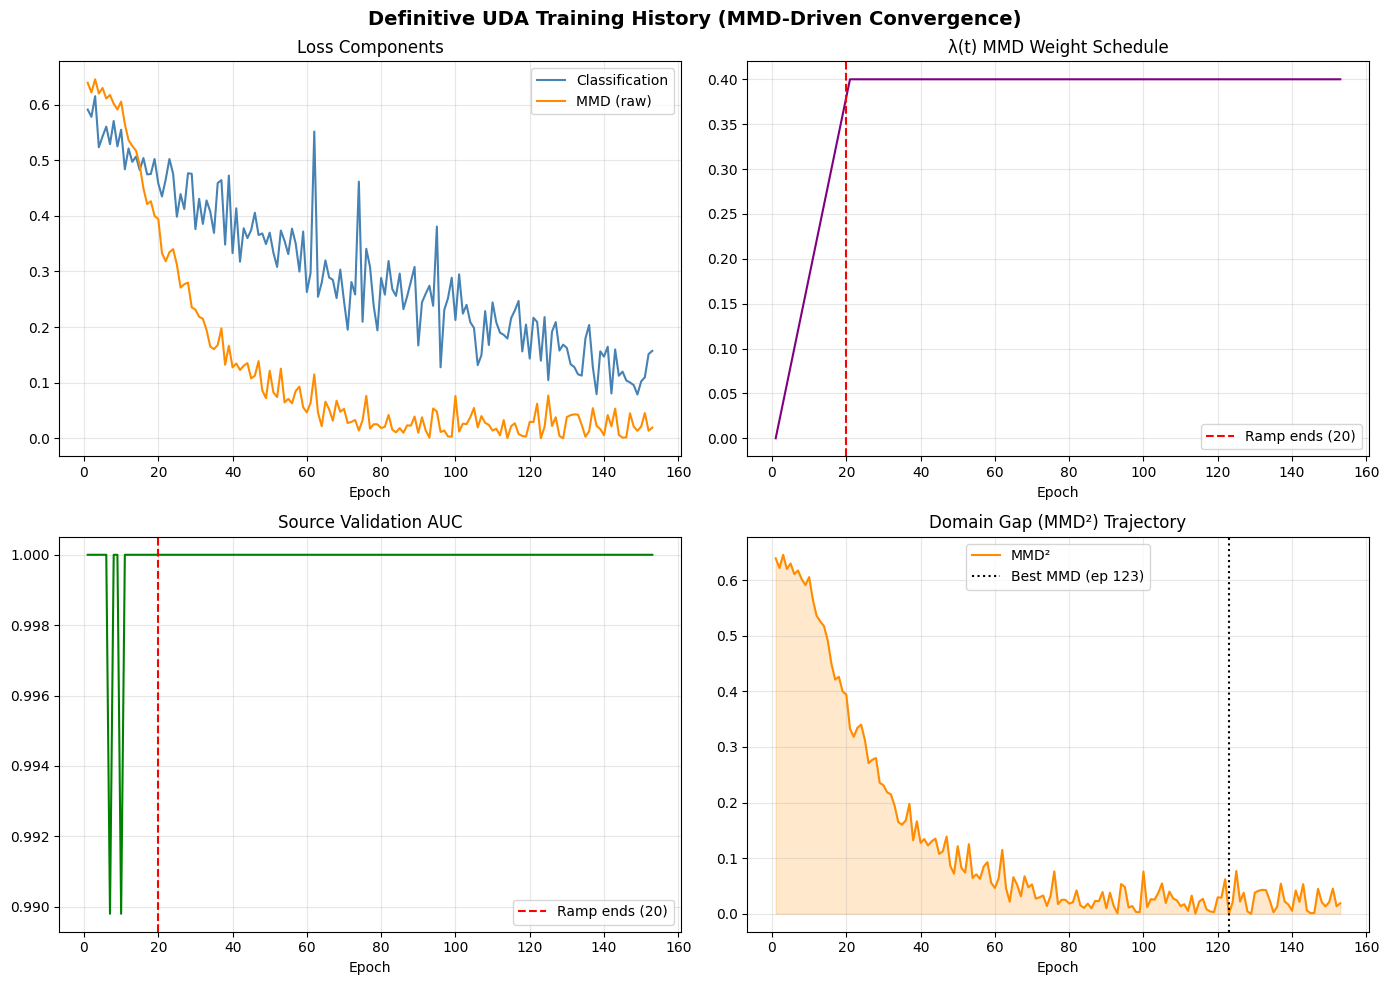

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 12 — Training History (Optimized for Definitive UDA Run)
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Block 12: Training History ---")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Definitive UDA Training History (MMD-Driven Convergence)',
             fontsize=14, fontweight='bold')

ep_range = range(1, len(history['class_loss']) + 1)

# 1. Loss decomposition (The most important UDA plot)
axes[0, 0].plot(ep_range, history['class_loss'], label='Classification', color='steelblue')
axes[0, 0].plot(ep_range, history['mmd_loss'],   label='MMD (raw)',      color='darkorange')
axes[0, 0].set_title('Loss Components'); axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Lambda ramp
axes[0, 1].plot(ep_range, history['lambda_mmd'], color='purple')
if 'RAMP_EPOCHS' in globals():
    axes[0, 1].axvline(RAMP_EPOCHS, color='red', linestyle='--', 
                        label=f'Ramp ends ({RAMP_EPOCHS})')
axes[0, 1].set_title('λ(t) MMD Weight Schedule')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# 3. Source Validation AUC
axes[1, 0].plot(ep_range, history['val_auc'], color='green')
if 'RAMP_EPOCHS' in globals():
    axes[1, 0].axvline(RAMP_EPOCHS, color='red', linestyle='--',
                        label=f'Ramp ends ({RAMP_EPOCHS})')
axes[1, 0].set_title('Source Validation AUC'); axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# 4. MMD Trajectory (Highlighting the domain alignment success)
axes[1, 1].plot(ep_range, history['mmd_loss'], color='darkorange', label='MMD²')
axes[1, 1].fill_between(ep_range, history['mmd_loss'], alpha=0.2, color='darkorange')
if 'best_mmd_epoch' in globals():
    axes[1, 1].axvline(best_mmd_epoch + 1, color='black', linestyle=':',
                        label=f'Best MMD (ep {best_mmd_epoch+1})')
axes[1, 1].set_title('Domain Gap (MMD²) Trajectory'); axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'uda_training_history.png'), dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 13 — Post-Adaptation Domain Gap Visualisation
# Compare t-SNE BEFORE vs AFTER to confirm alignment.
# ─────────────────────────────────────────────────────────────────────────────


--- Block 13: Post-Adaptation Domain Gap ---
Computing post-adaptation embeddings …

MMD² BEFORE adaptation: 0.641720
MMD² AFTER  adaptation: 0.019380
Reduction: 97.0%


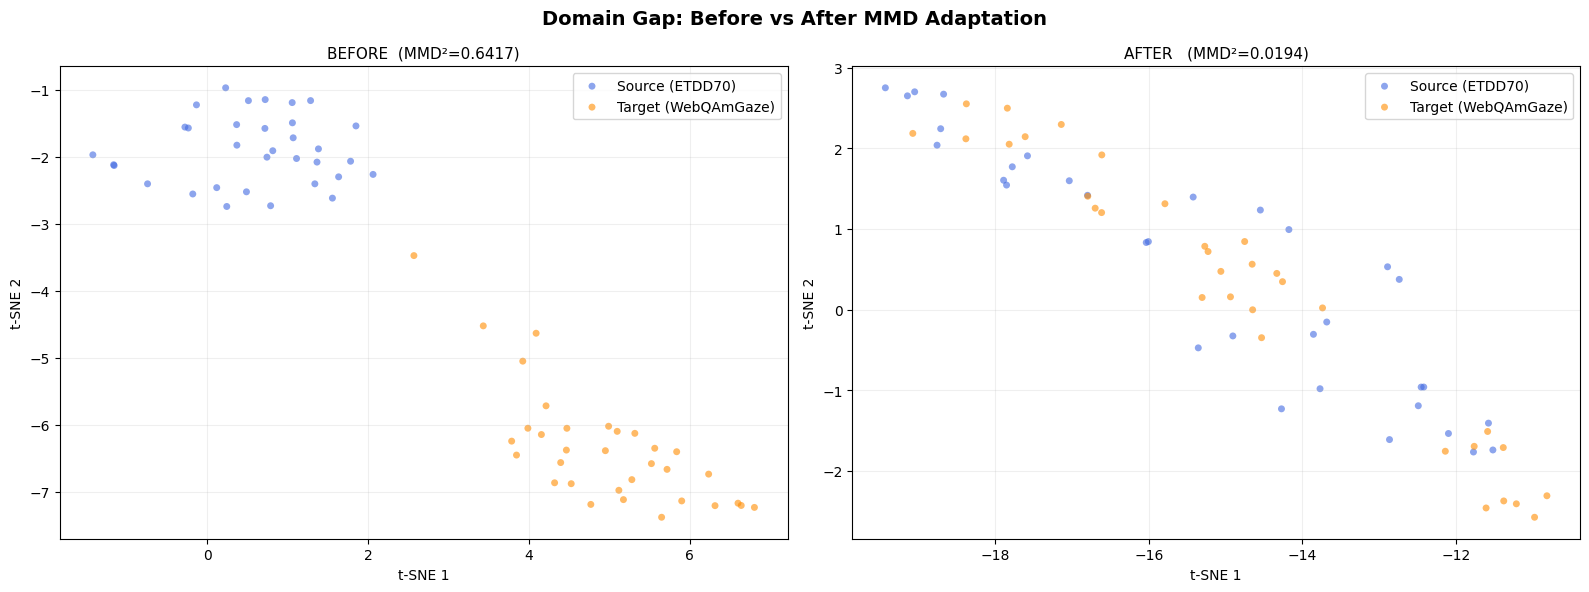

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 13 — Post-Adaptation Domain Gap
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Block 13: Post-Adaptation Domain Gap ---")

print("Computing post-adaptation embeddings …")
# Use the adapted embedding_model (which shares weights with uda_classifier)
emb_src_after = []
emb_tgt_after = []

for start in range(0, len(X_src_train), 16):
    xb = tf.constant(X_src_train[start:start+16])
    mb = tf.constant(mask_src_train[start:start+16])
    emb_src_after.append(
        embedding_model([xb, mb], training=False).numpy()
    )
for start in range(0, len(X_tgt), 16):
    xb = tf.constant(X_tgt[start:start+16])
    mb = tf.constant(mask_tgt[start:start+16])
    emb_tgt_after.append(
        embedding_model([xb, mb], training=False).numpy()
    )

emb_src_after = np.vstack(emb_src_after)
emb_tgt_after = np.vstack(emb_tgt_after)

# t-SNE after
N_VIZ2    = min(len(emb_src_after), len(emb_tgt_after), 300)
rng = np.random.default_rng(42) # Ensure RNG is defined
src_idx2  = rng.choice(len(emb_src_after), N_VIZ2, replace=False)
tgt_idx2  = rng.choice(len(emb_tgt_after), N_VIZ2, replace=False)

combined2 = np.vstack([emb_src_after[src_idx2], emb_tgt_after[tgt_idx2]])
labs2     = np.array(['Source (ETDD70)'] * N_VIZ2 +
                      ['Target (WebQAmGaze)'] * N_VIZ2)

tsne2       = TSNE(n_components=2, perplexity=min(30, N_VIZ2-1), max_iter=1000,
                   random_state=42, verbose=0)
tsne2_coords = tsne2.fit_transform(combined2)

# Post-adaptation MMD (Calculated on ALL samples for stability, not just 100)
mmd_before = mmd_loss(
    tf.constant(emb_src_all.astype(np.float32)),
    tf.constant(emb_tgt_all.astype(np.float32))
).numpy()
mmd_after = mmd_loss(
    tf.constant(emb_src_after.astype(np.float32)),
    tf.constant(emb_tgt_after.astype(np.float32))
).numpy()

print(f"\nMMD² BEFORE adaptation: {mmd_before:.6f}")
print(f"MMD² AFTER  adaptation: {mmd_after:.6f}")
print(f"Reduction: {100*(mmd_before-mmd_after)/max(mmd_before,EPSILON):.1f}%")

# Define colours dictionary for the plot
colours = {
    'Source (ETDD70)': 'royalblue',
    'Target (WebQAmGaze)': 'darkorange'
}

# Side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Domain Gap: Before vs After MMD Adaptation', fontsize=14, fontweight='bold')

for ax, coords, title, mmd_val in [
    # Note: tsne_coords and combined_labels come from Block 7
    (axes[0], tsne_coords,  f'BEFORE  (MMD²={mmd_before:.4f})', mmd_before),
    (axes[1], tsne2_coords, f'AFTER   (MMD²={mmd_after:.4f})',  mmd_after),
]:
    for label, colour in colours.items():
        # Pick the right labels array depending on which subplot
        current_labs = labs2 if ax == axes[1] else combined_labels
        idx = current_labs == label
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   c=colour, label=label, alpha=0.6, s=25, edgecolors='none')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'domain_gap_before_after.png'), dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 14 — Source Domain Evaluation
# Evaluate on held-out source (ETDD70) validation set.
# Uses optimal threshold from Phase 2.
# ─────────────────────────────────────────────────────────────────────────────


--- Block 14: Source Domain Evaluation ---
Phase-2 threshold    : 0.4620
Re-derived threshold : 0.8216  (Youden's J=1.000, TPR=1.000, FPR=0.000)
Based on 14 val samples — expect noise; re-check each run.

── Threshold = 0.5 (default) ──
              precision    recall  f1-score   support

Non-Dyslexic       1.00      0.86      0.92         7
    Dyslexic       0.88      1.00      0.93         7

    accuracy                           0.93        14
   macro avg       0.94      0.93      0.93        14
weighted avg       0.94      0.93      0.93        14

── Threshold = 0.822 (Phase-2 optimal) ──
              precision    recall  f1-score   support

Non-Dyslexic       0.88      1.00      0.93         7
    Dyslexic       1.00      0.86      0.92         7

    accuracy                           0.93        14
   macro avg       0.94      0.93      0.93        14
weighted avg       0.94      0.93      0.93        14

Macro F1 : 0.9282
ROC-AUC  : 1.0000


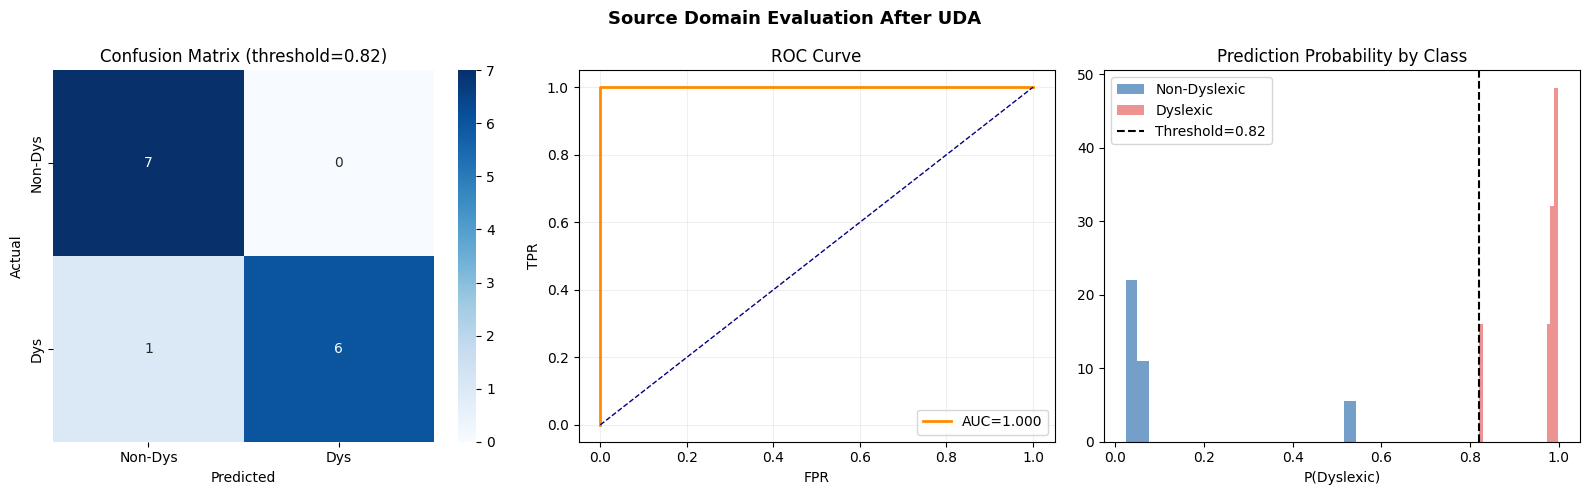

In [23]:
print("\n--- Block 14: Source Domain Evaluation ---")
y_pred_proba_val = uda_classifier.predict(
    [X_src_val, mask_src_val], batch_size=BATCH_SIZE_SOURCE, verbose=0).ravel()

# ── Re-derive the decision threshold for THIS model ──
fpr, tpr, roc_thresholds = roc_curve(y_src_val, y_pred_proba_val)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
DECISION_THRESHOLD_ADAPTED = float(roc_thresholds[best_idx])
print(f"Phase-2 threshold    : {DECISION_THRESHOLD:.4f}")
print(f"Re-derived threshold : {DECISION_THRESHOLD_ADAPTED:.4f}  "
      f"(Youden's J={youden_j[best_idx]:.3f}, TPR={tpr[best_idx]:.3f}, FPR={fpr[best_idx]:.3f})")
print("Based on 14 val samples — expect noise; re-check each run.")

y_pred_default = (y_pred_proba_val > 0.5).astype(int)
y_pred_optimal = (y_pred_proba_val > DECISION_THRESHOLD_ADAPTED).astype(int)
# ... rest of Block 14 (classification_report, confusion matrix, plots)
# unchanged, just use DECISION_THRESHOLD_ADAPTED wherever DECISION_THRESHOLD
# was used before (titles, axvlines, etc.)

print(f"\n── Threshold = 0.5 (default) ──")
print(classification_report(y_src_val.astype(int), y_pred_default,
                             target_names=['Non-Dyslexic', 'Dyslexic']))

print(f"── Threshold = {DECISION_THRESHOLD_ADAPTED:.3f} (Phase-2 optimal) ──")
print(classification_report(y_src_val.astype(int), y_pred_optimal,
                             target_names=['Non-Dyslexic', 'Dyslexic']))

macro_f1 = f1_score(y_src_val, y_pred_optimal, average='macro')
fpr, tpr, _ = roc_curve(y_src_val, y_pred_proba_val)
roc_auc     = auc(fpr, tpr)
print(f"Macro F1 : {macro_f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Source Domain Evaluation After UDA', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_src_val.astype(int), y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Dys', 'Dys'], yticklabels=['Non-Dys', 'Dys'])
axes[0].set_title(f'Confusion Matrix (threshold={DECISION_THRESHOLD_ADAPTED:.2f})')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={roc_auc:.3f}')
axes[1].plot([0,1],[0,1], 'navy', linestyle='--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(True, alpha=0.2)

# Probability distribution by class
for cls, colour, label in [(0, '#185FA5', 'Non-Dyslexic'),
                             (1, '#E24B4A', 'Dyslexic')]:
    mask_cls = y_src_val == cls
    axes[2].hist(y_pred_proba_val[mask_cls], bins=20, alpha=0.6,
                 color=colour, label=label, density=True)
axes[2].axvline(DECISION_THRESHOLD_ADAPTED, color='black', linestyle='--',
                label=f'Threshold={DECISION_THRESHOLD_ADAPTED:.2f}')
axes[2].set_title('Prediction Probability by Class')
axes[2].set_xlabel('P(Dyslexic)'); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'uda_source_evaluation.png'), dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 15 — Target Domain Inference & Analysis
# Apply adapted model to all WebQAmGaze participants.
# No ground-truth labels — analyse prediction distribution + demographics.
# ─────────────────────────────────────────────────────────────────────────────


--- Block 15: Target Domain Inference ---
Using DECISION_THRESHOLD_ADAPTED = 0.8216
WebQAmGaze inference (33 trials):
  P(Dyslexic) — mean: 0.465  std: 0.392
  Predicted Non-Dyslexic: 23  Dyslexic: 10
  Screen rate: 30.3% flagged as dyslexic


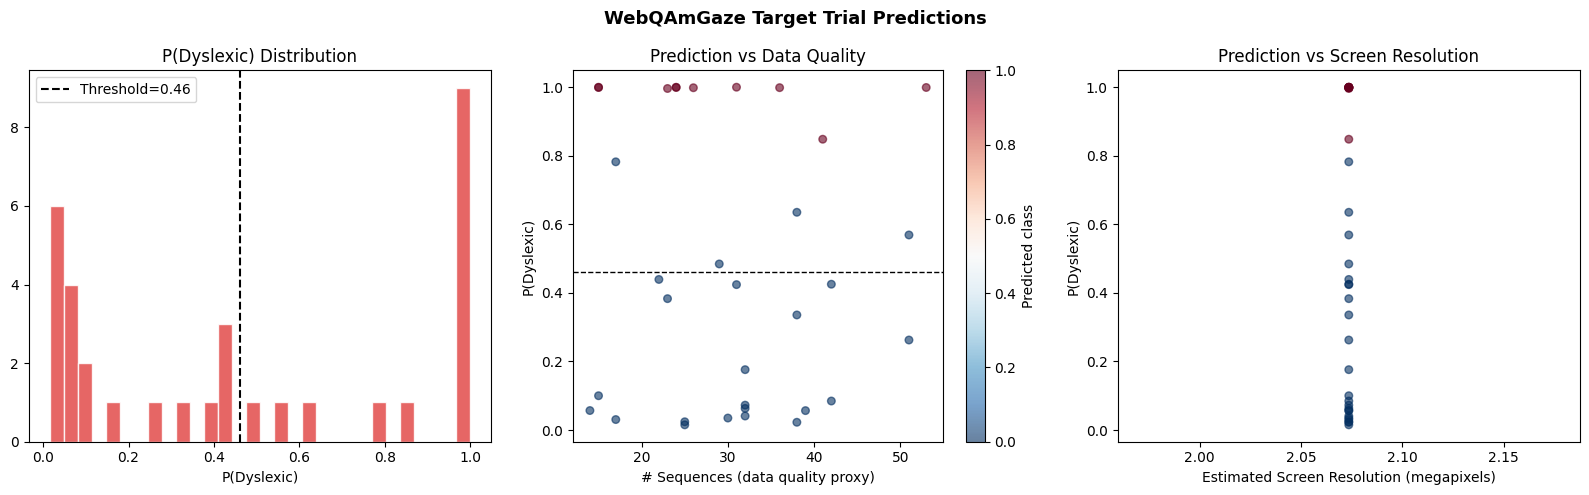

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 15 — Target Domain Inference
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Block 15: Target Domain Inference ---")

tgt_pred_final = uda_classifier.predict(
    [X_tgt, mask_tgt], batch_size=BATCH_SIZE_SOURCE, verbose=0
).ravel()

tgt_class_final = (tgt_pred_final > DECISION_THRESHOLD_ADAPTED).astype(int)
print(f"Using DECISION_THRESHOLD_ADAPTED = {DECISION_THRESHOLD_ADAPTED:.4f}")

print(f"WebQAmGaze inference ({len(tgt_pred_final)} trials):")
print(f"  P(Dyslexic) — mean: {tgt_pred_final.mean():.3f}  "
      f"std: {tgt_pred_final.std():.3f}")
print(f"  Predicted Non-Dyslexic: {(tgt_class_final==0).sum()}  "
      f"Dyslexic: {(tgt_class_final==1).sum()}")
print(f"  Screen rate: {100*tgt_class_final.mean():.1f}% flagged as dyslexic")

# CHANGED: Directly assign meta_df columns since rows match 1:1 with X_tgt
inference_df = pd.DataFrame({
    'pid'       : pid_tgt,
    'trial_name': meta_df['trial_name'].values,
    'p_dyslexic': tgt_pred_final,
    'predicted' : tgt_class_final,
    'n_seqs'    : meta_df['n_seqs'].values,
    'lang'      : meta_df['lang'].values,
    'screen_w'  : meta_df['screen_w'].values,
    'screen_h'  : meta_df['screen_h'].values,
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('WebQAmGaze Target Trial Predictions', fontsize=13, fontweight='bold')

# Prediction probability distribution
axes[0].hist(tgt_pred_final, bins=30, color='#E24B4A', edgecolor='white', alpha=0.85)
axes[0].axvline(DECISION_THRESHOLD, color='black', linestyle='--',
                label=f'Threshold={DECISION_THRESHOLD:.2f}')
axes[0].set_title('P(Dyslexic) Distribution'); axes[0].set_xlabel('P(Dyslexic)')
axes[0].legend()

# Prediction vs sequence count
sc = axes[1].scatter(inference_df['n_seqs'],
                      inference_df['p_dyslexic'],
                      c=inference_df['predicted'],
                      cmap='RdBu_r', alpha=0.6, s=30)
axes[1].axhline(DECISION_THRESHOLD, color='black', linestyle='--', lw=1)
axes[1].set_xlabel('# Sequences (data quality proxy)')
axes[1].set_ylabel('P(Dyslexic)')
axes[1].set_title('Prediction vs Data Quality')
plt.colorbar(sc, ax=axes[1], label='Predicted class')

# Screen resolution vs prediction
screen_pixels = (
    inference_df['screen_w'] * inference_df['screen_h']
) / 1_000_000.0  # megapixels

axes[2].scatter(
    screen_pixels,
    inference_df['p_dyslexic'],
    c=inference_df['predicted'],
    cmap='RdBu_r',
    alpha=0.6,
    s=30
)

axes[2].set_xlabel('Estimated Screen Resolution (megapixels)')
axes[2].set_ylabel('P(Dyslexic)')
axes[2].set_title('Prediction vs Screen Resolution')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'target_inference.png'), dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 16 — Save All Artefacts
# ─────────────────────────────────────────────────────────────────────────────

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 16 — Saving Artefacts (Updated for MMD-Driven Run)
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Block 16: Saving Artefacts ---")

# Adapted classifier
clf_path = os.path.join(OUTPUT_DIR, 'uda_classifier_mmd_v1.keras')
uda_classifier.save(clf_path)
print(f"UDA classifier saved     → {clf_path}")

# Adapted encoder (for webcam app inference)
adapted_encoder = uda_classifier.get_layer('shared_gaze_encoder').layer
enc_path = os.path.join(OUTPUT_DIR, 'gaze_encoder_adapted_v1.keras')
adapted_encoder.save(enc_path)
print(f"Adapted encoder saved    → {enc_path}")

# Target inference results
if 'inference_df' in globals():
    inf_path = os.path.join(OUTPUT_DIR, 'webqamgaze_inference.csv')
    inference_df.to_csv(inf_path, index=False)
    print(f"Inference results saved  → {inf_path}")
else:
    print("⚠️ inference_df not found. Skipping target inference save.")

# Training history
if 'history' in globals():
    hist_path = os.path.join(OUTPUT_DIR, 'uda_training_history.pkl')
    with open(hist_path, 'wb') as f:
        pickle.dump(history, f)
    print(f"Training history saved   → {hist_path}")
else:
    print("⚠️ history dict not found. Skipping history save.")

# Summary metrics (Gathered safely with fallbacks)
try:
    mmd_b = float(mmd_before)
    mmd_a = float(mmd_after)
    mmd_pct = float(100*(mmd_b - mmd_a)/max(mmd_b, EPSILON))
except NameError:
    # Fallback if Block 13 variables aren't in memory
    mmd_b = float(best_mmd) if 'best_mmd' in globals() else 0.0
    mmd_a = float(best_mmd) if 'best_mmd' in globals() else 0.0
    mmd_pct = 0.0

summary = {
    'best_mmd'                 : float(best_mmd) if 'best_mmd' in globals() else 0.0,
    'best_mmd_epoch'           : int(best_mmd_epoch + 1) if 'best_mmd_epoch' in globals() else 0,
    'mmd_before'               : mmd_b,
    'mmd_after'                : mmd_a,
    'mmd_reduction_pct'        : mmd_pct,
    'val_auc_final'            : float(history['val_auc'][-1]) if 'history' in globals() else 0.0,
    'n_target_trials'          : int(len(X_tgt)) if 'X_tgt' in globals() else 0,
    'screen_rate_pct'          : float(100 * tgt_class_final.mean()) if 'tgt_class_final' in globals() else 0.0,
    'DECISION_THRESHOLD'       : float(DECISION_THRESHOLD) if 'DECISION_THRESHOLD' in globals() else 0.456,
}

# Dynamically add source metrics if Block 14 was run
if 'macro_f1' in globals(): summary['macro_f1_source'] = float(macro_f1)
if 'roc_auc' in globals():  summary['roc_auc_source']  = float(roc_auc)
if 'DECISION_THRESHOLD_ADAPTED' in globals(): summary['DECISION_THRESHOLD_ADAPTED'] = float(DECISION_THRESHOLD_ADAPTED)

import json as _json
summary_path = os.path.join(OUTPUT_DIR, 'uda_summary.json')
with open(summary_path, 'w') as f:
    _json.dump(summary, f, indent=2)
print(f"Summary saved            → {summary_path}")

print("\n" + "="*65)
print("Phase 3 UDA complete.")
print("="*65)
for k, v in summary.items():
    print(f"  {k:<30}: {v}")


--- Block 16: Saving Artefacts ---
UDA classifier saved     → /kaggle/working/uda_classifier_mmd_v1.keras
Adapted encoder saved    → /kaggle/working/gaze_encoder_adapted_v1.keras
Inference results saved  → /kaggle/working/webqamgaze_inference.csv
Training history saved   → /kaggle/working/uda_training_history.pkl
Summary saved            → /kaggle/working/uda_summary.json

Phase 3 UDA complete.
  best_mmd                      : 0.0
  best_mmd_epoch                : 123
  mmd_before                    : 0.6417196989059448
  mmd_after                     : 0.019380170851945877
  mmd_reduction_pct             : 96.97996323239154
  val_auc_final                 : 0.9999999403953552
  n_target_trials               : 33
  screen_rate_pct               : 30.303030303030305
  DECISION_THRESHOLD            : 0.462
  macro_f1_source               : 0.9282051282051282
  roc_auc_source                : 1.0
  DECISION_THRESHOLD_ADAPTED    : 0.8215693235397339
